In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og
import src.colabfold as cf
import src.unitprot as up



import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import numpy as np  

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 681512 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [3]:
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
    )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 6.36GB/s]


VEP dataframe shape: (2028077, 72)


In [4]:
haplotypes = hs.get_haplotypes(cache_only=True,
                                tx_ids=vep_df['ENST'].unique()
                                ) 

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes:   0%|          | 0/1450 [00:00<?, ?it/s]

In [5]:
haps_df= hs.get_haplotype_names(haplotypes=haplotypes, 
                                as_df=True, 
                                split_variants=True) 

Getting haplotype names:   0%|          | 0/1450 [00:00<?, ?it/s]

In [6]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=True)
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/1450 [00:00<?, ?it/s]

Processing sample to haplotype name maps:   0%|          | 0/1450 [00:00<?, ?it/s]

/home/schilder/projects/VEP_protein/src/haplosaurus.py:2257: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<NA>' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  haps_to_ref.loc[:,["Gender"]] = pd.NA


,sample,ENST_haplosaurus,haplotype,Gender,Population,Super Population
0,REF,ENST00000001146,ENSP00000001146:REF,<NA>,REF,REF
5008,REF,ENST00000003084,ENSP00000003084:REF,<NA>,REF,REF
10016,REF,ENST00000005257,ENSP00000005257:REF,<NA>,REF,REF
15024,REF,ENST00000029410,ENSP00000029410:REF,<NA>,REF,REF
20032,REF,ENST00000037502,ENSP00000037502:REF,<NA>,REF,REF


array([[<Axes: title={'center': 'variant'}>]], dtype=object)

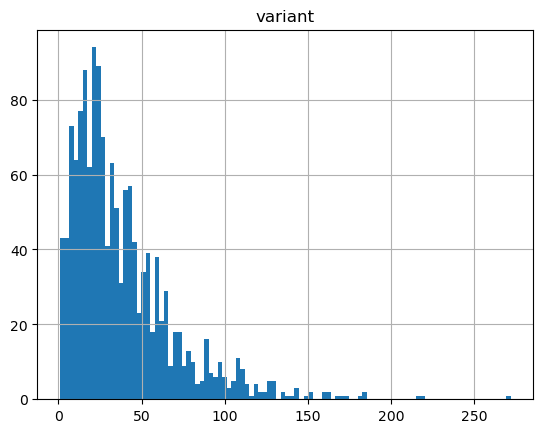

In [7]:
haps_df.groupby(["ENST"]).agg({"variant":"nunique"}).sort_values("variant", ascending=False).hist(bins=100)

## WT variant attribution analysis

Identify the WT variants (observed naturally occurring  in the  biobank cohort). 
Then find how frequency those variants are (inferred by extracting them from the haplotype names after expanding the data from the unique haplotype --> individual level).

Using side-by-side heatmaps we can find superpopulation x WT variant clusters that are frequent in a given superpopulation and/or high mean VEP (across all injected variants). 

In this way, we can identify (superpopulation-specific) WT variants that confer sensitivity to ClinVar variants in general.  

We could also recompute this plot to show only average VEP for a specific ClinVar variant of interest to see which WT variants confer sensitivity to it.

Getting haplotype frequencies:   0%|          | 0/1450 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations
Adding haplotype frequencies per population
Adding top superpopulation

Number of variants specific to each population:
specific_superpopulation
1000GENOMES:phase_3:AFR    14374
1000GENOMES:phase_3:EAS     9624
1000GENOMES:phase_3:SAS     8993
1000GENOMES:phase_3:EUR     6757
1000GENOMES:phase_3:AMR     4774
Name: count, dtype: int64

Percentage of population-specific haplotypes: 76.60%


/home/schilder/projects/VEP_protein/src/vep_analysis.py:2638: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  var_freqs_agg = var_freqs_agg.fillna(fillna)


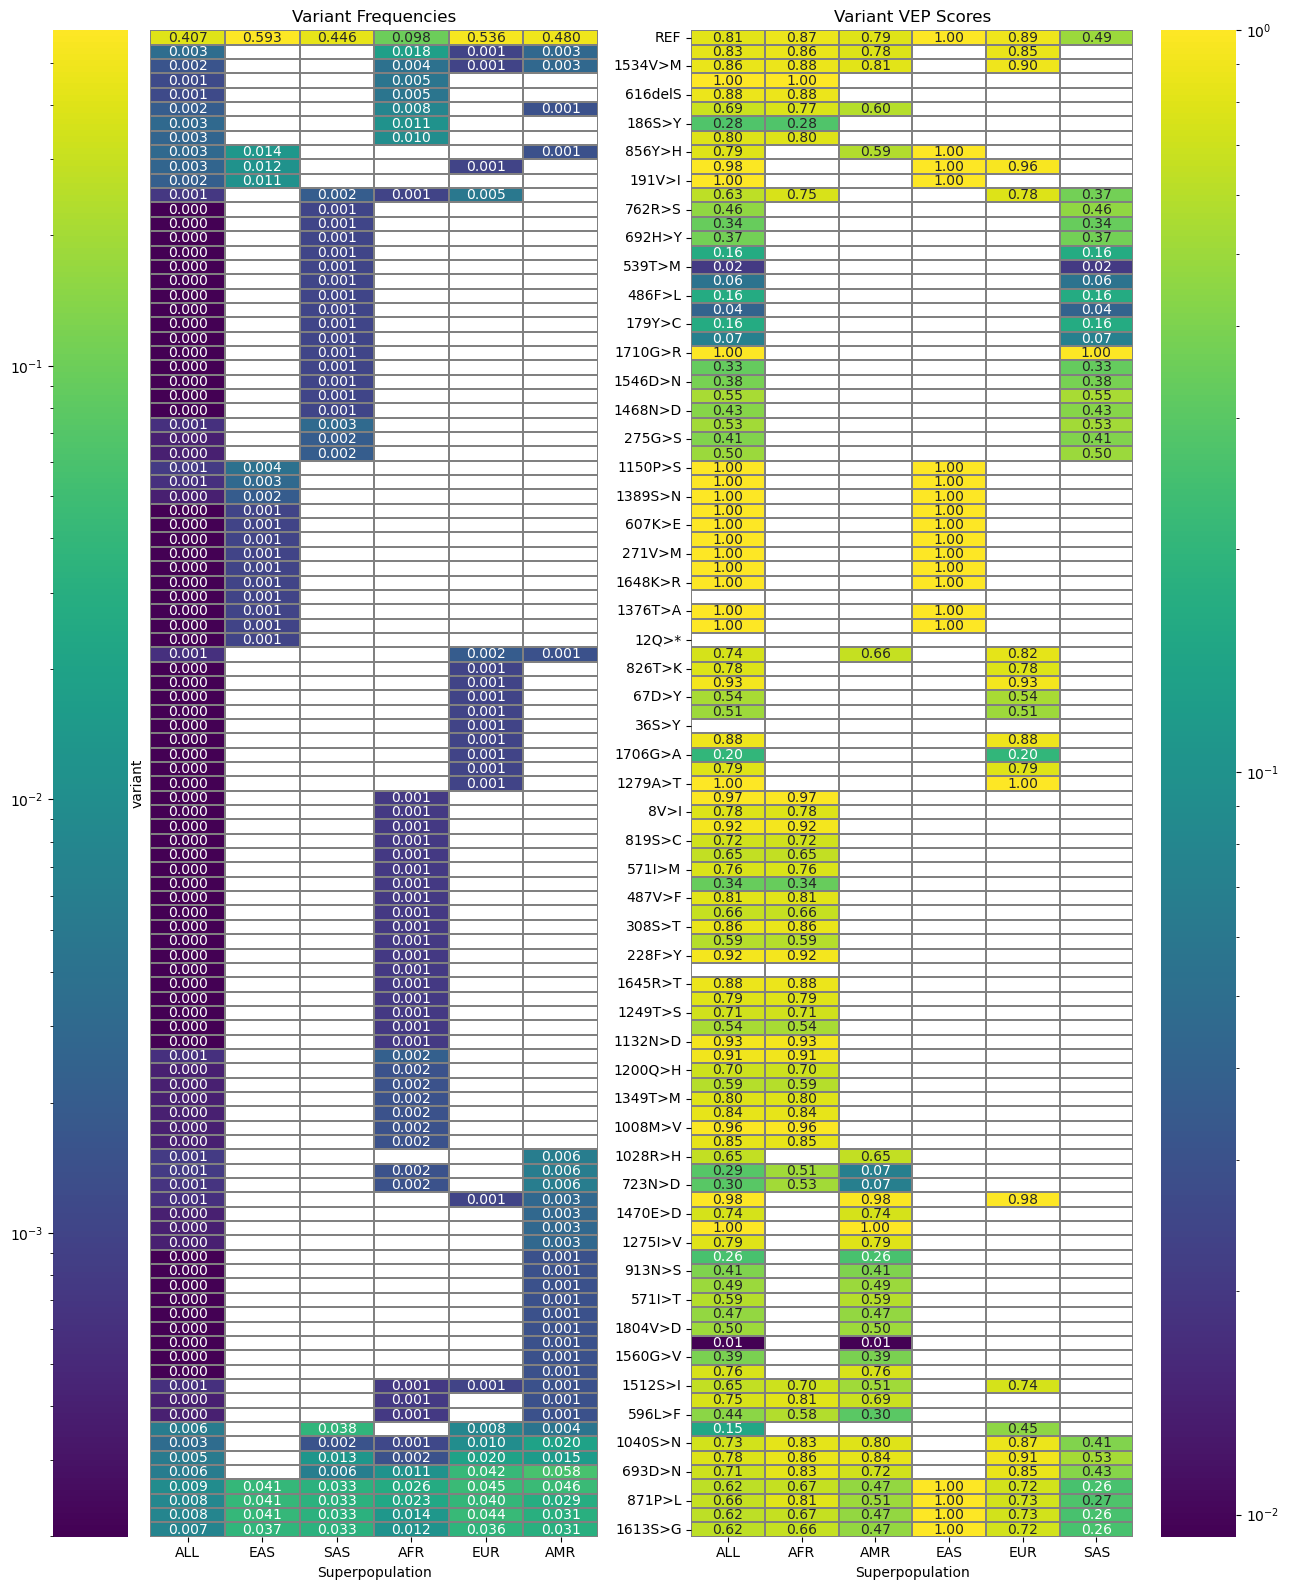

In [8]:
vep_prot, var_vep_agg, var_freqs_agg, fig = va.get_wt_variant_vep_scores(vep_df=vep_df, 
                                                                        haps_df=haps_df,
                                                                        haplotypes=haplotypes, 
                                                                        haps_to_samples=haps_to_samples,
                                                                        protein='NP_009225.1'
                                                                        )

### Dotplot

Same information as the dual heatmaps above, but condense into a single dotplot where the size is the variant frequency and the color is the mean VEP score.

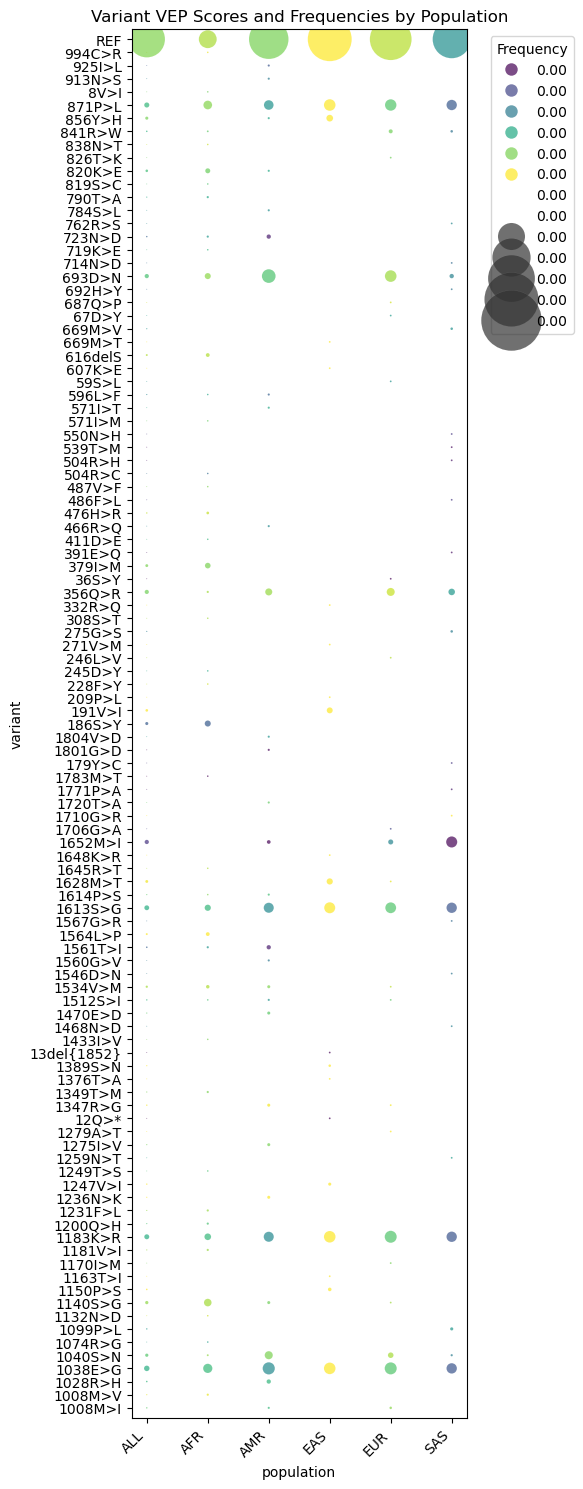

In [9]:
va.plot_wt_variant_vep_scores_dotplot(var_vep_agg, var_freqs_agg)

## Clinical variant x Individual heatmap

(2284104, 77)
Number of col clusters: 73


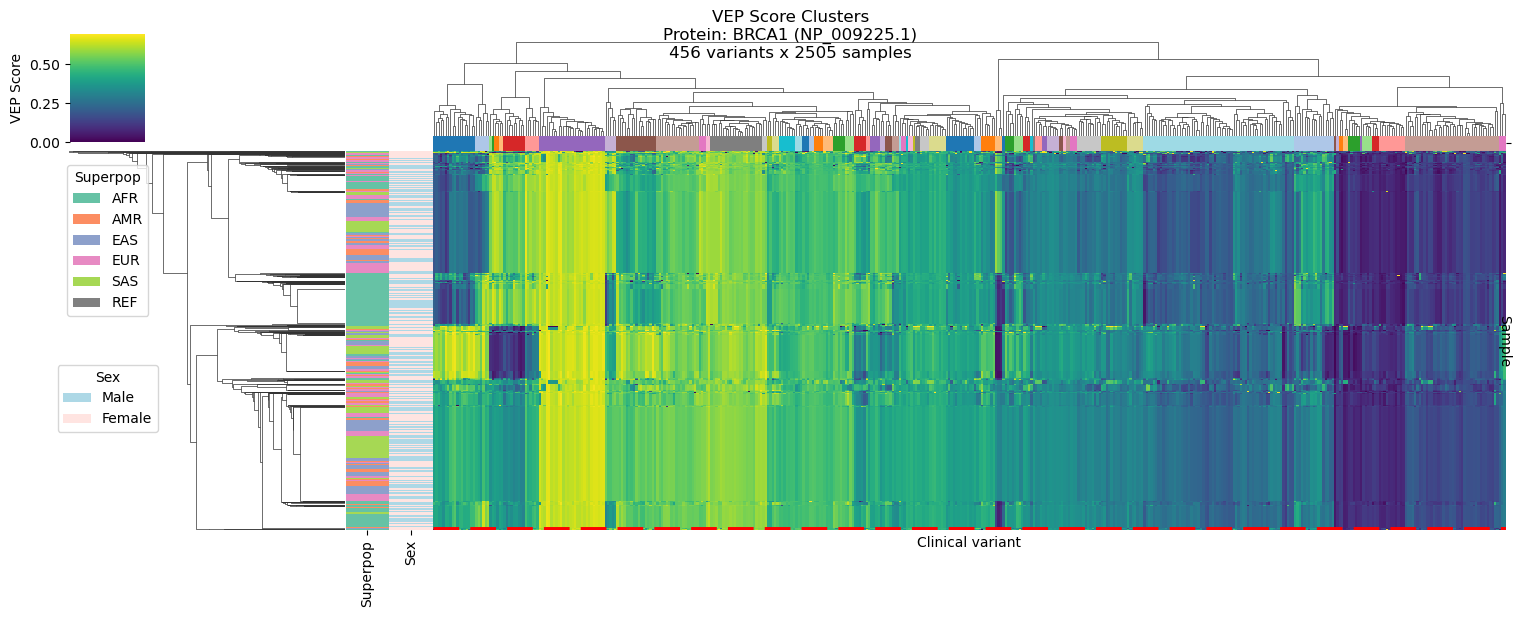

In [10]:
g1, variant_to_cluster = va.sample_by_mutant_clustermap(vep_df, 
                                                        haps_to_samples,
                                                        protein='NP_009225.1',
                                                        figsize=(15,6),
                                                        t=1.15)

## Clinica variant x WT variant sensitization heatmap

Compare mean VEP across WT variants for each injected ClinVar variant.

In [62]:
row_colors

,mutant_position,VEP
variant,,
8V>I,#f7fbff,#dfe318
12Q>*,#f7fbff,#3f4889
13del{1852},#f7fbff,#3f4889
36S>Y,#f7fbff,#23a983
59S>L,#f7fbff,#54c568
...,...,...
1771P>A,#f7fbff,#25838e
1783M>T,#f7fbff,#25858e
1801G>D,#f7fbff,#238a8d


Adding positions to WT variants
Adding positions to clinical variants
Sorting clinical variants by WT variant positions
Creating color palettes
Inverting scale
Normalizing rows
Creating mask
Creating column colors
Reindexing column colors
Creating row colors
Reindexing row colors
Dropping position column from column colors
Dropping position column from row colors
Creating clustermap


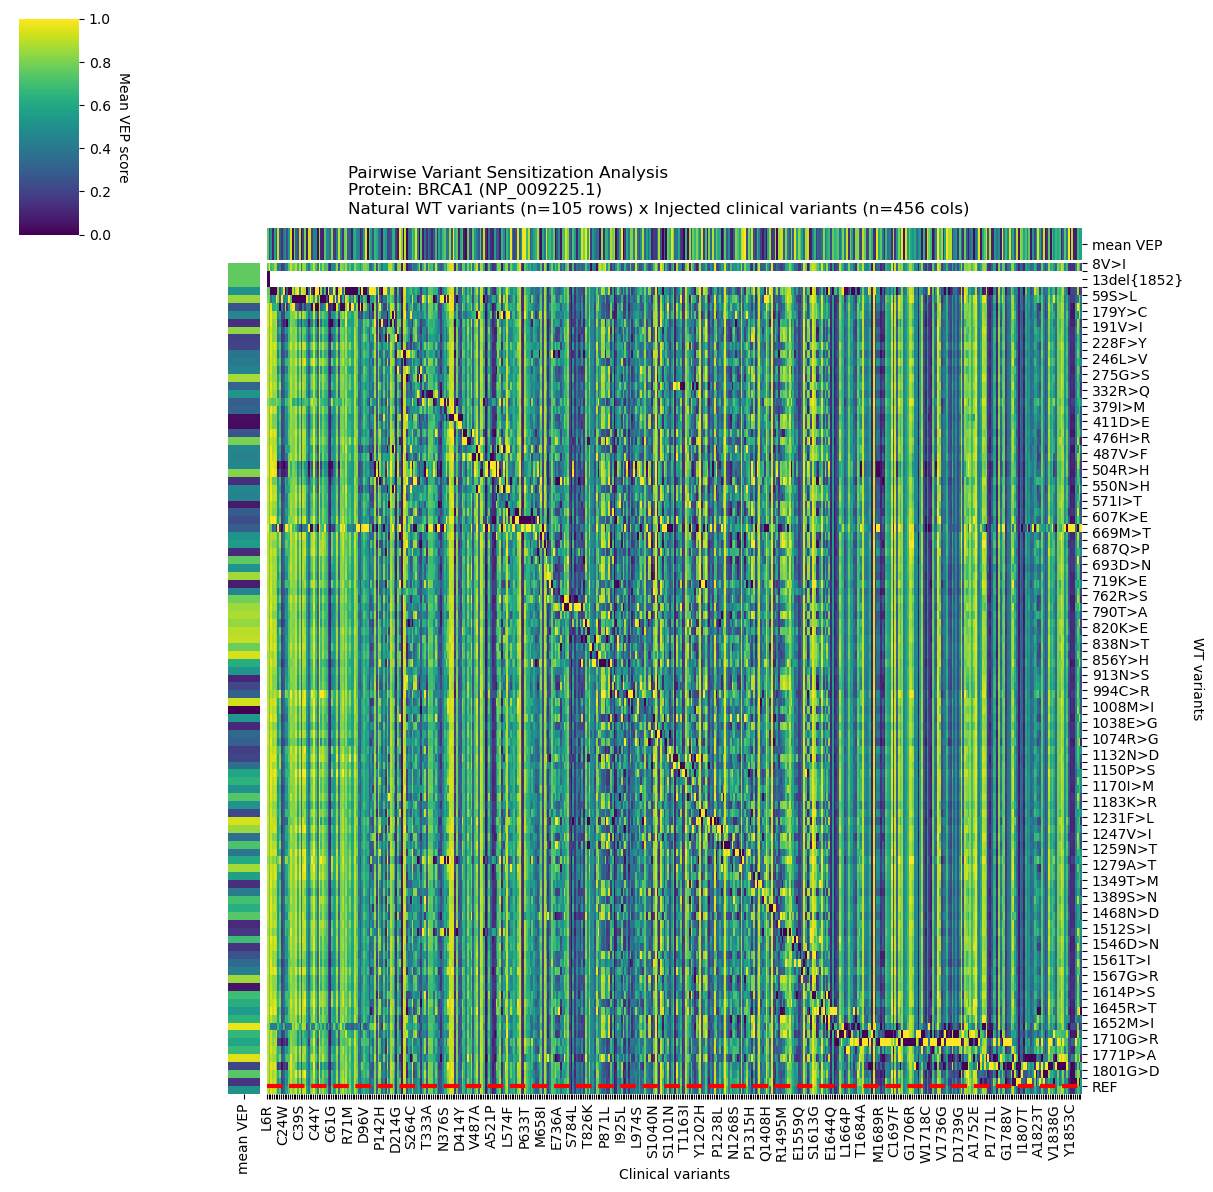

,mean VEP
mutant,
L6R,#60ca60
R7L,#3d4e8a
M18T,#21918c
M18K,#482071
M18R,#21a685
...,...
Y1853S,#481b6d
P1856S,#481b6d
I1858L,#38b977


In [81]:
g0, clinvar_vs_wt, row_colors, col_colors = va.pairwise_variant_sensitization_clustermap(vep_prot, 
                                            figsize=(12,12),
                                            row_cluster=False,
                                            col_cluster=False,
                                             title_y=1.05,
                                        #    show_position_per_col=True ,
                                        #     show_position_per_row=True,
                                             )

row_colors
col_colors

## 2D protein structure

### Import from PDB

The Protein Data Bank (PDB) utilizes two primary file formats for storing and exchanging protein structure information: the legacy PDB format and the more modern CIF (Crystallographic Information Framework) format, also known as PDBx/mmCIF. The CIF format is derived from the STAR format and has been adopted as the standard for deposition since 2014 due to limitations in the original PDB format. 

Here's a comparison of the key features of each format:
1. PDB Format:
Fixed-width format: Data fields are allocated a predetermined number of characters, which can be limiting for large protein complexes exceeding the assigned space.
Legacy format: While widely used due to its long history, the fixed-width format poses limitations, especially with larger protein complexes, and is being phased out.
Structure: Each line, or record, begins with a record name (e.g., "ATOM," "HETATM"), followed by data fields arranged in specific columns. 

2. CIF (PDBx/mmCIF) Format:
Expandable format: The CIF format uses a label-value structure, where data is explicitly named and separated by spaces, allowing for unlimited data content without encountering size restrictions.
Data blocks: CIF files are constructed by concatenating data blocks, each containing label and data columns.
PDB Standard: The CIF format has been the standard for PDB deposition since 2014.
Improved data representation: mmCIF enhances the representation of additional information alongside the atomic coordinates, unlike the limited support in the legacy PDB format. 

In summary: 

- PDB files: Older, fixed-width format, useful for smaller protein structures, but less flexible for large complexes. Still widely used for compatibility with older software.
- CIF files (PDBx/mmCIF): Newer, expandable format with no size restrictions, better suited for large macromolecular structures. The standard for new PDB depositions. 
It's important to note that while the CIF format is the preferred standard, many bioinformatics tools and programs continue to support the legacy PDB format. Conversion tools are available to facilitate the transition between formats. 

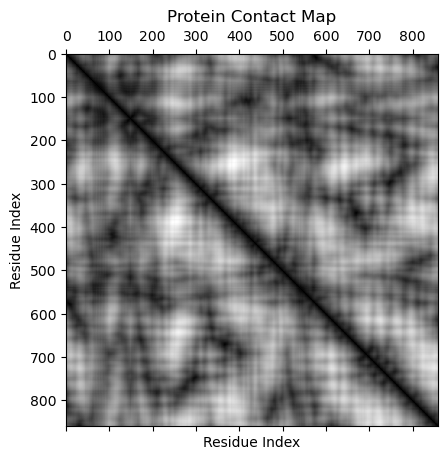

In [18]:
structure = cf.import_pdb("https://alphafold.ebi.ac.uk/files/AF-Q8CGX5-F1-model_v4.pdb") 

# Calculate the contact map
contact_map = cf.get_contact_map(structure)

# Plot the contact map
plt.matshow(contact_map, cmap='binary')
plt.title("Protein Contact Map")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()


### Import from mmCIF

File /home/schilder/.cache/alphafold_db/AF-P38398-F1-model_v4.cif already exists, skipping download.


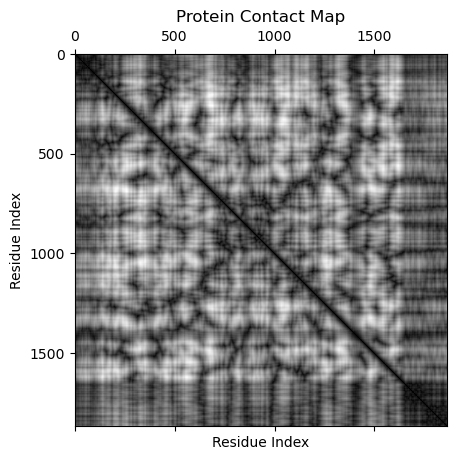

In [23]:
structure = cf.import_mmcif(protein_id = "P38398")

contact_map = cf.get_contact_map(structure, 
                                 max_distance=8.0, 
                                 continuous=True, 
                                 return_distance_map=True )

plt.matshow(contact_map, cmap='binary')
plt.title("Protein Contact Map")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()

In [26]:
plddt_df = cf.get_plddt(structure)

print(plddt_df["pLDDT"].describe())
plddt_df.head()

Number of residues: 1863
count    1863.000000
mean       41.285357
std        23.417639
min        19.560000
25%        27.935000
50%        30.660000
75%        36.660000
max        97.960000
Name: pLDDT, dtype: float64


,residue,pLDDT,confidence_category,confidence_label,confidence_color
0,1,41.59,very_low,Very low (pLDDT < 50),#FF7D45
1,2,45.81,very_low,Very low (pLDDT < 50),#FF7D45
2,3,48.11,very_low,Very low (pLDDT < 50),#FF7D45
3,4,63.99,low,Low (70 > pLDDT > 50),#FFDB13
4,5,61.73,low,Low (70 > pLDDT > 50),#FFDB13


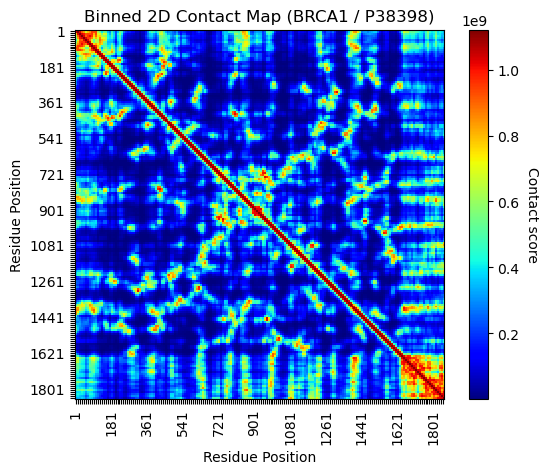

In [294]:
protein_name = "BRCA1"
protein_id = "P38398"

contact_map, contact_map_binned = cf.plot_contact_map(contact_map=contact_map, 
                    title=f"Binned 2D Contact Map ({protein_name} / {protein_id})",  
                    bin_size=10, 
                    log_before_bin=False, 
                    log_after_bin=False, 
                    max_labels=10, 
                    pow=4,
                    agg_func=np.nanmax)

In [29]:
vep_prot = utils.variants_to_positions(vep_prot)
vep_prot.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,variant_position
10485,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,NaN,NaN,NaN,NaN,NaN,-3.694999,NaN,6,likely_path,1710G>R,-3.315499,4.437071,1710.0
10453,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,NaN,NaN,NaN,NaN,NaN,-9.459467,NaN,6,likely_path,1710G>R,-3.315499,4.437071,1710.0
10484,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,NaN,NaN,NaN,NaN,NaN,-0.984293,NaN,6,path,1710G>R,-3.315499,4.437071,1710.0
10483,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,531241,17:43124044,C,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/R,aTg/aGg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>G,NP_009225.1:p.Met18Arg,-,NaN,NaN,531135,"MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777..."

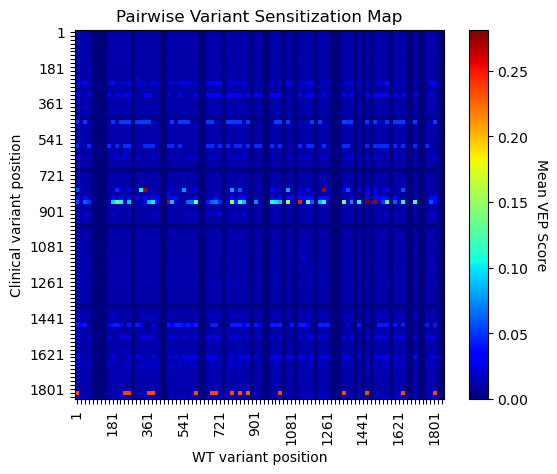

In [293]:
# Create empty matrix filled with zeros
matrix_size = 1863  # Total protein length
vep_matrix = np.zeros((matrix_size, matrix_size))
# Fill matrix with mean VEP values
for _, row in vep_prot.loc[vep_prot["variant"] != "REF"].iterrows():
    # Handle NaN values in variant_position
    if pd.isna(row['variant_position']):
        continue
    else:
        i = int(row['Protein_position']) - 1  # Convert to 0-based indexing
        j = int(row['variant_position']) - 1
        vep_matrix[i, j] = row['VEP']  # Only fill one direction to maintain row=Protein, col=variant

# Invert the matrix so that higher VEP scores are more red
vep_matrix = vep_matrix*-1

# Normalize each row to sum to 1, skipping NAs
normalize_rows = True
if normalize_rows:
    row_sums = np.nansum(vep_matrix, axis=1, keepdims=True)
    vep_matrix = np.divide(vep_matrix, row_sums, where=(row_sums!=0) & (row_sums!=np.nan))


# Normalize the whole matrix to a scale from 0 to 1
# vep_matrix = (vep_matrix - np.nanmin(vep_matrix)) / (np.nanmax(vep_matrix) - np.nanmin(vep_matrix))
# # Invert the matrix
# vep_matrix = 1 - vep_matrix

# Log
# vep_matrix = vep_matrix**1.05
# vep_matrix = np.log1p(vep_matrix)


import scipy.spatial.distance
corr_axis = None
if corr_axis == "x":
    # Calculate cosine similarity along rows
    vep_matrix = scipy.spatial.distance.cdist(vep_matrix, vep_matrix, metric='cosine')
    vep_matrix = np.nanmax(vep_matrix) - vep_matrix
elif corr_axis == "y":
    # Calculate cosine similarity along columns
    vep_matrix = scipy.spatial.distance.cdist(vep_matrix.T, vep_matrix.T, metric='cosine')
    vep_matrix = np.nanmax(vep_matrix) - vep_matrix

 

# Bin the matrix
bin_size=20
vep_matrix_binned = cf.bin_matrix(vep_matrix.copy(), bin_size=bin_size, agg_func=np.nanmax)
n_bins = vep_matrix_binned.shape[0]
# Invert the contact matrix
# vep_matrix = np.log10(vep_matrix + 1e-6)
# vep_matrix = np.nan_to_num(vep_matrix, nan=0) 


# Plot the contact matrix
# plt.figure(figsize=(12, 10))
plt.imshow(vep_matrix_binned, cmap='jet')
plt.colorbar().ax.set_ylabel("Mean VEP Score", 
                                rotation=270, 
                                va="bottom") 

plt.title('Pairwise Variant Sensitization Map')
plt.xlabel('WT variant position')
plt.ylabel('Clinical variant position')

cf.label_bins(bin_size, n_bins)

plt.show()


Contact map 95th percentile: 133.19568634033203
Expanding x-axis by 3
Expanding y-axis by 3
VEP matrix 95th percentile: 0.011489135393433053
High contact: 173538
High VEP: 173470
High both: 14536


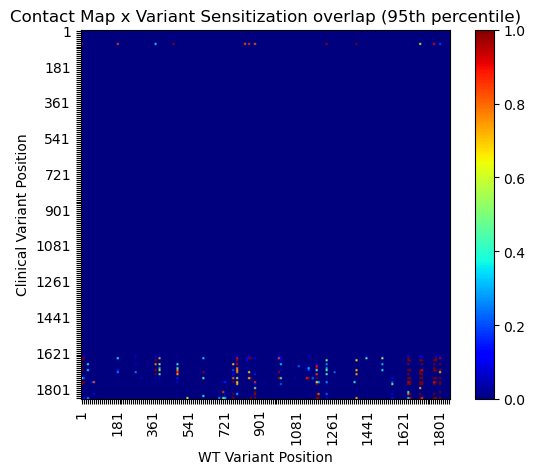

In [280]:
# Calculate 95th percentile for each matrix

method = "linear"

# Set diagonals to nan
# np.fill_diagonal(contact_map, np.nan)
# np.fill_diagonal(vep_matrix, np.nan)


pctl = [95,95]
# Create a copy of contact_map and set diagonal to nan

pctl1 = pctl[0]
# contact_map_no_diag = contact_map.copy()
# np.fill_diagonal(contact_map_no_diag, np.nan)
# contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
# print(f"Contact map {pctl1}th percentile:", contact_map_95th)

# Filter based on confidence category and ensure alignment with contact map
high_confidence_mask = plddt_df.set_index("residue").reindex(range(contact_map.shape[0]))["confidence_category"].isin(["high", "very_high"]).values 
# Apply mask to matrices
contact_map_no_diag = contact_map.copy()
np.fill_diagonal(contact_map_no_diag, np.nan)
# Set low confidence residues to nan
contact_map_no_diag[~high_confidence_mask] = np.nan
# Find 95th percentile
contact_map_95th = np.percentile(np.nan_to_num(contact_map_no_diag, nan=np.nanmedian(contact_map_no_diag)), q=pctl1, method=method)
print(f"Contact map {pctl1}th percentile:", contact_map_95th)




# Create a copy of vep_matrix and set diagonal to nan
pctl2=pctl[1]
vep_matrix_no_diag = cf.expand_matrix(vep_matrix_binned, target_size=1863)
np.fill_diagonal(vep_matrix_no_diag, np.nan)
vep_matrix_95th = np.percentile(np.nan_to_num(vep_matrix_no_diag, nan=np.nanmedian(vep_matrix_no_diag)), q=pctl2, method=method)
print(f"VEP matrix {pctl2}th percentile:", vep_matrix_95th)

# Find indices where both matrices exceed their 95th percentile
high_contact = contact_map_no_diag > contact_map_95th
high_vep = vep_matrix_no_diag > vep_matrix_95th
high_both = np.logical_and(high_contact, high_vep)

print(f"High contact: {high_contact.sum()}")
print(f"High VEP: {high_vep.sum()}")
print(f"High both: {high_both.sum()}")



bin_size=10
high_both_binned = cf.bin_matrix(high_both, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = high_both_binned.shape[0]
# high_both_binned = np.log10(high_both_binned+1e-6)

plt.imshow(high_both_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar()
plt.xlabel("WT Variant Position")
plt.ylabel("Clinical Variant Position")
plt.title(f"Contact Map x Variant Sensitization overlap ({pctl1}th percentile)")
plt.show()





Expanding x-axis by 3
Expanding y-axis by 3


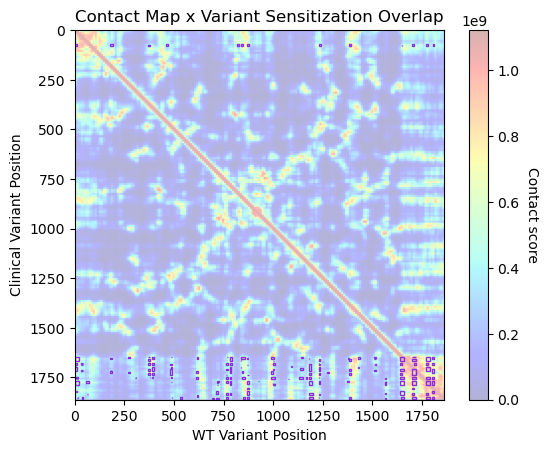

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1863, 1863), dtype=int32)

In [295]:
# Find clusters in the original high_both matrix
from scipy.ndimage import label


contact_map_rebinned = cf.expand_matrix(contact_map_binned, target_size=1863)


# Create a 2D structure array for label function
structure = np.ones((3, 3))  # 3x3 structure for 8-connectivity
labeled_array, num_features = label(high_both, structure=structure)

# Plot contact map with rectangles around clusters
# plt.figure(figsize=(10, 10))
plt.imshow(contact_map_rebinned, cmap='jet', alpha=0.3)  # Added alpha to make heatmap more transparent
plt.colorbar().ax.set_ylabel("Contact score", 
                                rotation=270, 
                                va="bottom") 

# Draw rectangles around each cluster
for i in range(1, num_features + 1):
    # Get coordinates of points in this cluster
    cluster_points = np.where(labeled_array == i)
    if len(cluster_points[0]) > 0:
        min_row, max_row = np.min(cluster_points[0]), np.max(cluster_points[0])
        min_col, max_col = np.min(cluster_points[1]), np.max(cluster_points[1])
        
        # Draw rectangle
        rect = plt.Rectangle((min_col - 0.5, min_row - 0.5), 
                           max_col - min_col + 1, 
                           max_row - min_row + 1,
                           fill=False, 
                           edgecolor='blueviolet', 
                           linewidth=1.0)  # Increased linewidth for better visibility
        plt.gca().add_patch(rect)


plt.xlabel("WT Variant Position")
plt.ylabel("Clinical Variant Position")
plt.title(f"Contact Map x Variant Sensitization Overlap")
plt.show()

# Return the labeled clusters for further analysis
labeled_array


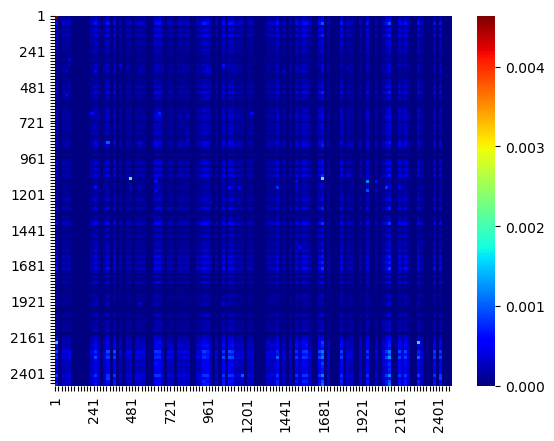

In [215]:
norm_rows=True
if norm_rows:
    vep_matrix = cf.normalize_rows(vep_matrix) 

vep_matrix_binned = cf.bin_matrix(vep_matrix, bin_size=15, agg_func=np.nanmean)




sns.heatmap(vep_matrix_binned, cmap='jet')
cf.label_bins(20, vep_matrix_binned.shape[0])

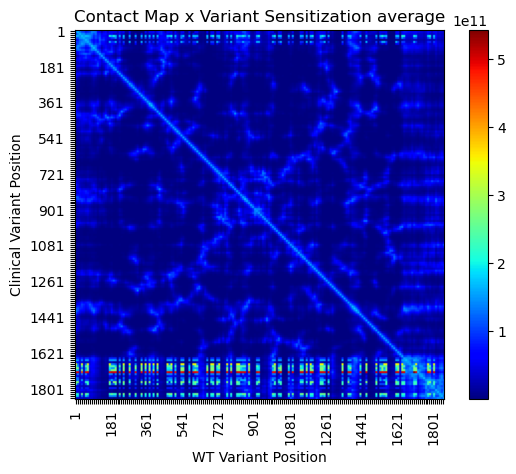

Where both matrices exceed 95th percentile: 24311


In [168]:
# np.fill_diagonal(high_both, False)

avg_matrix = cf.average_matrices([contact_map_no_diag, 
                                    vep_matrix_no_diag
                                       ], 
                                      weights=[1, 15], 
                                      normalize_scale=False, 
                                      normalize_rows=[False, False],
                                      use_max=True
                                      )
 
avg_matrix = avg_matrix**5
# Set values below 95th percentile to 0
# vep_matrix_no_diag[~high_both] = np.nan
# contact_map_no_diag[~high_both] = np.nan

norm_rows=False
if norm_rows:
    row_sums = np.nansum(avg_matrix, axis=1, keepdims=True)
    avg_matrix = np.divide(avg_matrix, row_sums, 
                                where=(row_sums!=0) & (row_sums!=np.nan))

bin_size=10
avg_matrix_binned = cf.bin_matrix(avg_matrix, bin_size=bin_size, agg_func=np.nanmean) 
n_bins = avg_matrix_binned.shape[0]

plt.imshow(avg_matrix_binned, cmap='jet')
cf.label_bins(bin_size, n_bins)
plt.colorbar()
plt.xlabel("WT Variant Position")
plt.ylabel("Clinical Variant Position")
plt.title(f"Contact Map x Variant Sensitization average")
plt.show()
 

# Print the results
print(f"Where both matrices exceed {pctl1}th percentile:", high_both.sum())
 


## GWAS validation

In [60]:
gwas_file = "/home/schilder/projects/data/GWAS/Coignard2021/cimba_onco_icogs_brca1_combined_results.zip"

import polars as pl
from zipfile import ZipFile

gwas_chr = pl.read_csv(
    ZipFile(gwas_file).read(os.path.basename(gwas_file).replace(".zip", ".txt")),
    separator="\t",
    infer_schema_length=10000,  # Increase schema inference length
    null_values=["NULL"],  # Add NULL to null values
    schema_overrides={  # Specify dtypes for problematic columns
        "icogs2_bc_info": pl.Float64,
        "icogs2_bc_freq": pl.Float64,
        "icogs2_bc_effect": pl.Float64,
        "icogs2_bc_se": pl.Float64,
        "icogs2_bc_pval": pl.Float64
    }
).filter(pl.col("chr")==17)

print(gwas_chr.shape)
gwas_chr.head()

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
0,1:10177:A:AC,1,10177,1_10177_A_AC,0.392506,0.398130,0,0,A,AC,0.555004,0.980880,-0.019305,0.032704,0.825712,0.988616,-0.011449,0.051993,A,AC,0.311558,-0.077779,0.081056,0.311558,-0.045582,0.121294,a,ac,0.6065,0.0275,0.0303,0.3647,++,0.6063,0.0167,0.0478,0.72600,++
1,rs145072688:10352:T:TA,1,10352,1_10352_T_TA,0.427835,0.468706,0,0,T,TA,0.967027,1.001241,0.001240,0.030006,0.593130,1.025777,0.025450,0.047632,T,TA,0.316558,-0.032721,0.079860,0.316558,-0.136273,0.119649,t,ta,0.5731,0.0030,0.0281,0.9160,-+,0.5732,-0.0033,0.0443,0.94010,-+
2,rs376342519:10616:CCGCCGTTGCAAAGGCGCGCCG:C,1,10616,1_10616_CCGCCGTTGCAAAGGCGCGCCG_C,0.993082,0.809506,0,0,CCGCCGTTGCAAAGGCGCGCCG,C,0.330438,0.875211,-0.133290,0.136956,0.105802,1.423685,0.353248,0.218411,CCGCCGTTGCAAAGGCGCGCCG,C,0.252285,0.039259,0.565683,0.252285,0.185878,0.823488,ccgccgttgcaaaggcgcgccg,c,0.0069,0.1333,0.1370,0.3304,+?,0.0069,-0.3532,0.2184,0.10580,-?
3,1:10642:G:A,1,10642,1_10642_G_A,0.000459,0.450396,0,0,G,A,0.370544,1.802596,0.589228,0.658021,0.087413,6.720283,1.905130,1.114628,G,A,0.100978,3.154975,2.049150,0.100978,-4.593819,3.195176,a,g,0.0005,0.5892,0.6580,0.3705,+?,0.0005,1.9051,1.1146,0.08741,+?
4,1:11008:C:G,1,11008,1_11008_C_G,0.092459,0.563082,0,0,C,G,0.163313,1.066661,0.064533,0.046293,0.281914,0.923641,-0.079431,0.073819,C,G,0.324832,0.062103,0.136031,0.324832,0.137146,0.204345,c,g,0.9077,-0.0643,0.0438,0.1424,--,0.9077,0.0544,0.0694,0.43300,+-


In [ ]:
brca1_coords ="chr17:41196312-41277381" # They use hg37 coordinates in this GWAS, so we will too
gwas_brca1 = gwas_chr.filter(
    (pl.col("position")>=int(brca1_coords.split(":")[1].split("-")[0])) &
    (pl.col("position")<=int(brca1_coords.split(":")[1].split("-")[1]))
).to_pandas() 

print(gwas_brca1.shape)
gwas_brca1.head()

(383, 38)


,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction
0,rs8176320,17,41196363,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++
1,rs184237074:41196368:C:T,17,41196368,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++
2,chr17_41196408_A_G,17,41196408,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++
3,17:41196762:C:T,17,41196762,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?
4,rs33947868:41196821:CT:C,17,41196821,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++


In [119]:
# Convert coordinates from hg19 to hg38 using pyliftover
from pyliftover import LiftOver

# Initialize the liftover converter
lo = LiftOver('hg19', 'hg38')

# Create a list to store new positions
new_positions = []
gwas_brca1['position_hg19'] = gwas_brca1['position']
# Convert each position
for pos in gwas_brca1['position_hg19']:
    # Convert position (returns list of converted positions)
    converted = lo.convert_coordinate('chr17', pos)
    if converted:
        # Take the first converted position
        new_positions.append(converted[0][1])
    else:
        # If conversion failed, keep original position
        new_positions.append(pos)

# Update positions in original dataframe
gwas_brca1['position'] = new_positions
 

gwas_brca1.head()

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg19,site
0,rs8176320,17,43044346,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,41196363,chr17:43044346-43044347_C_T
1,rs184237074:41196368:C:T,17,43044351,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,41196368,chr17:43044351-43044352_C_T
2,chr17_41196408_A_G,17,43044391,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,41196408,chr17:43044391-43044392_G_A
3,17:41196762:C:T,17,43044745,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,41196762,chr17:43044745-43044746_C_T
4,rs33947868:41196821:CT:C,17,43044804,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,41196821,chr17:43044804-43044805_CT_C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,43124747,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,41276764,chr17:43124747-43124748_TTTTTG_T
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,43125092,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,41277109,chr17:43125092-43125093_TCCCTCGCGACCTACAAACTGC...
380,rs799905:41277187:G:C,17,43125170,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,41277187,chr17:43125170-43125171_G_C
381,rs273898672:41277277:G:A,17,43125260,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,41277277,chr17:43125260-43125261_G_A


In [155]:
gwas_brca1 = utils.add_variant_name(gwas_brca1, chrom_col="chr", start_col="position", end_col=None, ref_col="onco_baseline", alt_col="onco_effect", alias="site", force=True)
gwas_brca1

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg19,site,name
0,rs8176320,17,43044346,17_41196363_C_T,0.010623,1.000000,1,2,C,T,0.834758,1.020382,0.020177,0.096726,0.627179,1.079047,0.076078,0.156635,C,T,1.000000,-0.318184,0.195231,1.000000,0.294215,0.296046,t,c,0.0106,-0.0465,0.0867,0.59150,+-,0.0106,0.1238,0.1385,0.3713,++,41196363,chr17:43044346-43044347_C_T,chr17:43044346-43044346_C_T
1,rs184237074:41196368:C:T,17,43044351,17_41196368_C_T,0.001541,0.425617,0,0,C,T,0.423880,0.724759,-0.321916,0.402541,0.695557,1.280689,0.247398,0.632206,C,T,0.396595,0.529475,0.511562,0.396595,0.053791,0.731616,t,c,0.0034,0.0037,0.3163,0.99080,-+,0.0036,0.1646,0.4784,0.7307,++,41196368,chr17:43044351-43044352_C_T,chr17:43044351-43044351_C_T
2,chr17_41196408_A_G,17,43044391,17_41196408_G_A,0.321649,1.000000,1,2,G,A,0.158789,0.969772,-0.030695,0.021782,0.735544,1.011794,0.011725,0.034714,G,A,0.999000,-0.114552,0.049868,0.999000,0.016810,0.073913,a,g,0.3217,-0.0441,0.0200,0.02705,--,0.3217,0.0126,0.0314,0.6874,++,41196408,chr17:43044391-43044392_G_A,chr17:43044391-43044391_G_A
3,17:41196762:C:T,17,43044745,17_41196762_C_T,0.001000,0.546583,0,0,C,T,0.483681,1.373350,0.317253,0.452963,0.974007,1.025207,0.024895,0.764035,None,None,NaN,NaN,NaN,NaN,NaN,NaN,t,c,0.0010,0.3173,0.4530,0.48370,+?,0.0010,0.0249,0.7640,0.9740,+?,41196762,chr17:43044745-43044746_C_T,chr17:43044745-43044745_C_T
4,rs33947868:41196821:CT:C,17,43044804,17_41196821_CT_C,0.517402,0.812000,0,0,CT,C,0.037397,0.954094,-0.046993,0.022578,0.934264,0.997040,-0.002964,0.035938,CT,C,0.766650,0.000703,0.051231,0.766650,-0.056892,0.076678,ct,c,0.4803,0.0392,0.0207,0.05755,+-,0.4801,0.0127,0.0325,0.6969,++,41196821,chr17:43044804-43044806_CT_C,chr17:43044804-43044804_CT_C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,rs377617416:41276764:TTTTTG:T,17,43124747,17_41276764_TTTTTG_T,0.001000,0.292181,0,0,TTTTTG,T,0.778045,1.173781,0.160230,0.568458,0.451471,2.022455,0.704312,0.935386,TTTTTG,T,0.255055,-0.395183,0.948052,0.255055,0.634204,1.325604,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,41276764,chr17:43124747-43124753_TTTTTG_T,chr17:43124747-43124747_TTTTTG_T
379,17:41277109:TCCCTCGCGACCTACAAACTGCCC:T,17,43125092,17_41277109_TCCCTCGCGACCTACAAACTGCCC_T,0.001000,0.357545,0,0,TCCCTCGCGACCTACAAACTGCCC,T,0.027655,0.268856,-1.313579,0.596500,0.215936,3.183575,1.158005,0.935832,TCCCTCGCGACCTACAAACTGCCC,T,0.538584,0.487958,0.890254,0.538584,1.283738,1.252522,t,tccctcgcgacctacaaactgccc,0.0013,-0.7554,0.4955,0.12740,-+,0.0014,1.2030,0.7497,0.1086,++,41277109,chr17:43125092-43125116_TCCCTCGCGACCTACAAACTGC...,chr17:43125092-43125092_TCCCTCGCGACCTACAAACTGC...
380,rs799905:41277187:G:C,17,43125170,17_41277187_G_C,0.336402,0.994377,0,0,G,C,0.401445,0.982050,-0.018113,0.021587,0.687469,1.013930,0.013834,0.034388,G,C,0.994117,-0.102707,0.049498,0.994117,0.002390,0.073303,c,g,0.3362,-0.0316,0.0198,0.10990,--,0.3361,0.0118,0.0311,0.7054,++,41277187,chr17:43125170-43125171_G_C,chr17:43125170-43125170_G_C
381,rs273898672:41277277:G:A,17,43125260,17_41277277_G_A,0.001000,0.770209,0,0,G,A,0.618723,1.176321,0.162392,0.326311,0.466181,1.431425,0.358670,0.492201,G,A,0.458022,-1.064996,1.532646,0.458022,0.989916,2.110159,a,g,0.0010,0.1092,0.3192,0.73230,+-,0.0010,0.3912,0.4793,0.4144,++,41277277,chr17:43125260-43125261_G_A,chr17:43125260-43125260_G_A


In [156]:
vep_prot = utils.add_variant_name(vep_prot, chrom_col="#CHROM", start_col="POS", end_col=None, ref_col="REF", alt_col="ALT", alias="site", force=True)
vep_prot

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,site,name
0,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,None,None,None,NaN,NaN,-3.694999,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_T,chr17:43124044-431240441_A_T
1,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,None,None,None,NaN,NaN,-9.459467,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43106528-43106529_C_A,chr17:43106528-431065281_C_A
2,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,None,None,None,NaN,NaN,-0.984293,NaN,6,path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_G,chr17:43124044-431240441_A_G
3,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,531241,17:43124044,C,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/R,aTg/aGg,-,M

In [ ]:
vep_prot = utils.variants_to_positions(vep_prot)

gwas_vep = gwas_brca1.merge(vep_prot, on="site", how="inner")
gwas_vep

,rs_id,chr,position,var_name,exp_freq_a1,onco_bc_info,typed,type,onco_baseline,onco_effect,onco_bc_p,onco_bc_hr,onco_bc_beta,onco_bc_se,onco_oc_p,onco_oc_hr,onco_oc_beta,onco_oc_se,icogs_baseline,icogs_effect,icogs2_bc_info,icogs2_bc_beta,icogs2_bc_se,icogs2_oc_info,icogs2_oc_beta,icogs2_oc_se,onco_icogs_effect,onco_icogs_baseline,onco_icogs_bc_freq,onco_icogs_bc_effect,onco_icogs_bc_se,onco_icogs_bc_pval,onco_icogs_bc_direction,onco_icogs_oc_freq,onco_icogs_oc_effect,onco_icogs_oc_se,onco_icogs_oc_pval,onco_icogs_oc_direction,position_hg19,site,name_x,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,name_y,variant_position
0,rs28897696,17,43063903,17_41215920_T_G,0.003377,1.0,1,3,G,T,0.979107,0.995375,-0.004636,0.177026,0.220045,0.713777,-0.337185,0.274937,G,T,1.0,0.278795,0.336494,1.0,-0.187173,0.468843,t,g,0.0034,0.0568,0.1567,0.71690,-+,0.0035,-0.2988,0.2372,0.20770,--,41215920,chr17:43063903-43063904_G_T,chr17:43063903-43063903_G_T,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,A1708E,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-11.756889,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43063903,55407,G,T,.,PASS,55407,17:43063903,T,672,NM_007294.4,Transcript,missense_variant,5236,5123,1708,A/E,gCg/gAg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5123C>A,NP_009225.1:p.Ala1708Glu,-,NaN,NaN,70074,MedGen:CN221562|Human_Phenotype_Ontology:HP:00...,Breast_and/or_ovarian_cancer|Breast_neoplasm|n...,NC_000017.11:g.43063903G>T,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,28897696,NaN,BRCA1-HCI:BRCA1_00045|ClinGen:CA003252|UniProt...,None,None,None,NaN,NaN,-8.791383,NaN,6,path,1710G>R,-3.315499,4.437071,chr17:43063903-430639031_G_T,1710.0
1,rs28897696,17,43063903,17_41215920_T_G,0.003377,1.0,1,3,G,T,0.979107,0.995375,-0.004636,0.177026,0.220045,0.713777,-0.337185,0.274937,G,T,1.0,0.278795,0.336494,1.0,-0.187173,0.468843,t,g,0.0034,0.0568,0.1567,0.71690,-+,0.0035,-0.2988,0.2372,0.20770,--,41215920,chr17:43063903-43063904_G_T,chr17:43063903-43063903_G_T,ENSP00000350283:1150P>S,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,A1708E,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-11.492083,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43063903,55407,G,T,.,PASS,55407,17:43063903,T,672,NM_007294.4,Transcript,missense_variant,5236,5123,1708,A/E,gCg/gAg,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5123C>A,NP_009225.1:p.Ala1708Glu,-,NaN,NaN,70074,MedGen:CN221562|Human_Phenotype_Ontology:HP:00...,Breast_and/or_ovarian_cancer|Breast_neoplasm|n...,NC_000017.11:g.43063903G>T,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,28897696,NaN,BRCA1-HCI:BRCA1_00045|ClinGen:CA003252|UniProt...,None,None,None,NaN,NaN,-8.791383,NaN,6,path,1150P>S,-3.311127,4.436836,chr17:43063903-430639031_G_T,1150.0
2,rs28897696,17,43063903,17_41215920_T_G,0.003377,1.0,1,3,G,T,0.979107,0.995375,-0.004636,0.177026,0.220045,0.713777,-0.337185,0.274937,G,T,1.0,0.278795,0.336494,1.0,-0.187173,0.46884

| **Protein (HGVS)** | **Abbrev.** | **cDNA**  | **Domain** | **Evidence Strength**                                                           | **Support PMIDs**                              |
| ------------------ | ----------- | --------- | ---------- | ------------------------------------------------------------------------------- | ---------------------------------------------- |
| **p.Cys61Gly**     | C61G        | c.181T>G  | RING       | Pathogenic (ClinVar 3★, founder mutation, strong functional & segregation data） | 7894493, 9525870, 11278247, 20103620, 20507347 |
| **p.Met1775Arg**   | M1775R      | c.5324T>G | BRCT       | Pathogenic (ClinVar 3★, disrupted phosphopeptide binding, HDR loss）             | 26913838, 30209399                             |
| **p.Arg1699Gln**   | R1699Q      | c.5096G>A | BRCT–N     | Pathogenic (reduced penetrance, expert-panel reviewed)                          | 28490613, 23867111, 21473589, 11157798         |
| **p.Trp1837Cys**   | W1837C      | c.5511G>T | BRCT2      | Pathogenic (functional assays, hotspot residue)                                 | 20516115, 27802165, 30209399, 31124283         |
| **p.Gly1706Glu**   | G1706E      | c.5117G>A | BRCT       | Pathogenic (functional impairment confirmed)                                    | 26913838, …                                    |
| **p.Ala1708Val**   | A1708V      | c.5123C>T | BRCT       | Pathogenic (found in families, functionally deleterious)                        | 26913838, …                                    |
| **p.Thr1685Pro**   | T1685P      | c.5053A>C | BRCT       | Likely Pathogenic (functional assays suggest loss)                              | 29185120                                       |
| **p.Asp1692His**   | D1692H      | c.5074G>C | BRCT       | Pathogenic via splicing disruption (mini‑gene assay)                            | 29185120                                       |
| **p.Asp1692Asn**   | D1692N      | c.5074G>A | BRCT       | Pathogenic via splicing effects                                                 | 29185120                                       |
| **p.Gly1803Ala**   | G1803A      | c.5408G>C | BRCT2      | Pathogenic via splice/truncation                                                | 29185120                                       |


Source: https://chatgpt.com/share/684f32c8-3994-8008-9fb1-46b3a2525148

In [192]:
# Create DataFrame from the table data
clinvar_variants = pd.DataFrame({
    'Protein_HGVS': ['p.Cys61Gly', 'p.Met1775Arg', 'p.Arg1699Gln', 'p.Trp1837Cys', 
                     'p.Gly1706Glu', 'p.Ala1708Val', 'p.Thr1685Pro', 'p.Asp1692His',
                     'p.Asp1692Asn', 'p.Gly1803Ala'],
    'Abbrev': ['C61G', 'M1775R', 'R1699Q', 'W1837C', 'G1706E', 'A1708V', 'T1685P',
               'D1692H', 'D1692N', 'G1803A'],
    'cDNA': ['c.181T>G', 'c.5324T>G', 'c.5096G>A', 'c.5511G>T', 'c.5117G>A', 
             'c.5123C>T', 'c.5053A>C', 'c.5074G>C', 'c.5074G>A', 'c.5408G>C'],
    'Domain': ['RING', 'BRCT', 'BRCT–N', 'BRCT2', 'BRCT', 'BRCT', 'BRCT', 'BRCT',
               'BRCT', 'BRCT2'],
    'Evidence_Strength': [
        'Pathogenic (ClinVar 3★, founder mutation, strong functional & segregation data）',
        'Pathogenic (ClinVar 3★, disrupted phosphopeptide binding, HDR loss）',
        'Pathogenic (reduced penetrance, expert-panel reviewed)',
        'Pathogenic (functional assays, hotspot residue)',
        'Pathogenic (functional impairment confirmed)',
        'Pathogenic (found in families, functionally deleterious)',
        'Likely Pathogenic (functional assays suggest loss)',
        'Pathogenic via splicing disruption (mini‑gene assay)',
        'Pathogenic via splicing effects',
        'Pathogenic via splice/truncation'
    ],
    'Support_PMIDs': [
        '7894493, 9525870, 11278247, 20103620, 20507347',
        '26913838, 30209399',
        '28490613, 23867111, 21473589, 11157798',
        '20516115, 27802165, 30209399, 31124283',
        '26913838, …',
        '26913838, …',
        '29185120',
        '29185120',
        '29185120',
        '29185120'
    ]
})
clinvar_variants


,Protein_HGVS,Abbrev,cDNA,Domain,Evidence_Strength,Support_PMIDs
0,p.Cys61Gly,C61G,c.181T>G,RING,"Pathogenic (ClinVar 3★, founder mutation, stro...","7894493, 9525870, 11278247, 20103620, 20507347"
1,p.Met1775Arg,M1775R,c.5324T>G,BRCT,"Pathogenic (ClinVar 3★, disrupted phosphopepti...","26913838, 30209399"
2,p.Arg1699Gln,R1699Q,c.5096G>A,BRCT–N,"Pathogenic (reduced penetrance, expert-panel r...","28490613, 23867111, 21473589, 11157798"
3,p.Trp1837Cys,W1837C,c.5511G>T,BRCT2,"Pathogenic (functional assays, hotspot residue)","20516115, 27802165, 30209399, 31124283"
4,p.Gly1706Glu,G1706E,c.5117G>A,BRCT,Pathogenic (functional impairment confirmed),"26913838, …"
5,p.Ala1708Val,A1708V,c.5123C>T,BRCT,"Pathogenic (found in families, functionally de...","26913838, …"
6,p.Thr1685Pro,T1685P,c.5053A>C,BRCT,Likely Pathogenic (functional assays suggest l...,29185120
7,p.Asp1692His,D1692H,c.5074G>C,BRCT,Pathogenic via splicing disruption (mini‑gene ...,29185120
8,p.Asp1692Asn,D1692N,c.5074G>A,BRCT,Pathogenic via splicing effects,29185120
9,p.Gly1803Ala,G1803A,c.5408G>C,BRCT2,Pathogenic via splice/truncation,29185120


In [ ]:
risk_variants = utils.intersect(clinvar_variants["Abbrev"].tolist(), clinvar_vs_wt.columns.tolist())
print(len(risk_variants))
risk_variants 

7


['C61G', 'W1837C', 'R1699Q', 'G1803A', 'G1706E', 'D1692H', 'M1775R']

In [12]:
def identify_outliers(df):
    import scipy.stats as stats
    import pandas as pd
    
    # Initialize lists to store results
    columns = []
    variants = []
    values = []
    outlier_types = []
    z_scores = []
    p_values = []  # New list to store p-values
    
    for col in df.columns:
        # Calculate mean and standard deviation
        mean = df[col].mean()
        std = df[col].std()
        
        # Identify values more than 2 standard deviations from mean
        outliers = df[col][abs(df[col] - mean) > 2 * std]
        
        if not outliers.empty:
            # Add high outliers
            high_outliers = outliers[outliers > mean]
            for idx, val in high_outliers.items():
                columns.append(col)
                variants.append(idx)
                values.append(val)
                outlier_types.append('high')
                z = (val - mean) / std
                z_scores.append(z)
                # Calculate two-tailed p-value from z-score
                p_values.append(2 * (1 - stats.norm.cdf(abs(z))))
            
            # Add low outliers
            low_outliers = outliers[outliers < mean]
            for idx, val in low_outliers.items():
                columns.append(col)
                variants.append(idx)
                values.append(val)
                outlier_types.append('low')
                z = (val - mean) / std
                z_scores.append(z)
                # Calculate two-tailed p-value from z-score
                p_values.append(2 * (1 - stats.norm.cdf(abs(z))))
    
    # Create DataFrame from results
    df =  pd.DataFrame({
        'clinical_variant': columns,
        'wt_variant': variants,
        'value': values,
        'outlier_type': outlier_types,
        'z_score': z_scores,
        'p_value': p_values  # Add p-values to DataFrame
    })
    # Apply FDR correction to p-values
    from statsmodels.stats.multitest import multipletests

    # Get the p-values and apply FDR correction
    # rejected: Boolean array indicating which hypotheses were rejected after FDR correction
    # (True means the null hypothesis was rejected, i.e. the result is statistically significant)
    significant, p_adjusted, _, _ = multipletests(df['p_value'], method='fdr_bh')

    # Add adjusted p-values to DataFrame
    df['p_adjusted'] = p_adjusted
    df['significant'] = significant

    # Sort by adjusted p-value
    df = df.sort_values('p_adjusted')
    return df

# Get outlier analysis and display results
outlier_df = identify_outliers(clinvar_vs_wt)
 
# Filter to most sig results
outlier_sig = outlier_df[
        (outlier_df['significant']) &  # Must be signifiacant after FDR correction
        (abs(outlier_df['z_score']) > 4.5) &  # Must have very extreme z-scores
        (outlier_df['p_adjusted'] < 0.001)  # Must have very small adjusted p-values
    ]
    
print(outlier_sig.shape)

# Create figure and axis
plt.figure(figsize=(10,10))

# Create heatmap with muted colors
sns.heatmap(clinvar_vs_wt, cmap='viridis', cbar_kws={'label': 'VEP Score'}, alpha=0.3)

# Get top variant pairs from outlier_sig
top_pairs = outlier_sig

# Add rectangles around significant pairs
for _, row in top_pairs.iterrows():
    # Get indices for the pair
    wt_idx = clinvar_vs_wt.index.get_loc(row['wt_variant'])  # Row index
    clinvar_idx = clinvar_vs_wt.columns.get_loc(row['clinical_variant'])  # Column index
    
    # Set color based on outlier type
    color = 'red' if row['outlier_type'] == 'high' else 'blue'
    
    # Create rectangle at the intersection of the variant pair
    rect = plt.Rectangle((clinvar_idx, wt_idx), 1, 1, 
                        fill=False, 
                        edgecolor=color,
                        linewidth=1)
    plt.gca().add_patch(rect)

plt.title('VEP Scores Heatmap with Top Variant Pairs Highlighted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

outlier_sig

NameError: name 'clinvar_vs_wt' is not defined

In [313]:
vep_prot["mutant"].unique()

array(['M18K', 'C47F', 'M18T', 'M18R', 'L22S', 'C24R', 'C24G', 'C24S',
       'C24W', 'C27Y', 'C27F', 'E33D', 'P34R', 'T37K', 'T37R', 'C39R',
       'Q1811R', 'P1812A', 'D1813N', 'D1818G', 'N1819S', 'A1823T',
       'A1823P', 'G1788A', 'G1788V', 'M1775K', 'M1775R', 'P1776H',
       'L1780P', 'M1783L', 'C1787Y', 'R7L', 'Y1853H', 'Y1853S', 'Y1853C',
       'P1856S', 'I1858L', 'P1859R', 'H1860Q', 'I1824N', 'A1830S',
       'V1833M', 'A1823S', 'E1794D', 'L1800F', 'G1801D', 'V1833G',
       'W1837R', 'K1750R', 'R1751G', 'R1751Q', 'A1752P', 'A1752E',
       'R1753S', 'D1757Y', 'L1764P', 'P1771R', 'P1771L', 'M1775V',
       'D1739E', 'G1748S', 'G1748R', 'G1748D', 'E1849K', 'T1720A',
       'Q1721P', 'S1722P', 'S1722F', 'I1723T', 'D1733G', 'V1736F',
       'V1736A', 'V1736G', 'G1738R', 'G1738E', 'G1738V', 'D1739H',
       'D1739Y', 'D1739G', 'P1749R', 'D1739V', 'T1700I', 'K1702Q',
       'K1702I', 'L1705P', 'G1706R', 'G1706E', 'G1706A', 'G1706V',
       'A1708E', 'V1713L', 'V1713G', 'V1714G', 

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,site,name,variant_position,mutant_position
0,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,None,None,None,NaN,NaN,-3.694999,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_T,chr17:43124044-431240441_A_T,1710.0,18
1,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,None,None,None,NaN,NaN,-9.459467,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43106528-43106529_C_A,chr17:43106528-431065281_C_A,1710.0,47
2,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,None,None,None,NaN,NaN,-0.984293,NaN,6,path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_G,chr17:43124044-431240441_A_G,1710.0,18
3,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,531241,17:43124044,C,672,NM

In [311]:
utils.variants_to_positions(vep_prot)

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,variant,variant_VEP_mean,variant_VEP_std,site,name,variant_position
0,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.554015,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,55559,A,T,.,PASS,55559,17:43124044,T,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/K,aTg/aAg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>A,NP_009225.1:p.Met18Lys,-,NaN,NaN,70226,"MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...","Breast-ovarian_cancer,_familial,_susceptibilit...",NC_000017.11:g.43124044A>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003549,None,None,None,NaN,NaN,-3.694999,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_T,chr17:43124044-431240441_A_T,1710.0
1,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,C47F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.820170,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43106528,54247,C,A,.,PASS,54247,17:43106528,A,672,NM_007294.4,Transcript,missense_variant,253,140,47,C/F,tGc/tTc,-,MODERATE,-,-1,-,-,-,C,C,-,NM_007294.4:c.140G>T,NP_009225.1:p.Cys47Phe,-,NaN,NaN,68914,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Breast...,NC_000017.11:g.43106528C>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001623|5_prime...",1,80357150,NaN,ClinGen:CA000952,None,None,None,NaN,NaN,-9.459467,NaN,6,likely_path,1710G>R,-3.315499,4.437071,chr17:43106528-43106529_C_A,chr17:43106528-431065281_C_A,1710.0
2,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-5.401980,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,37664,A,G,.,PASS,37664,17:43124044,G,672,NM_007294.4,Transcript,missense_variant,166,53,18,M/T,aTg/aCg,-,MODERATE,-,-1,-,-,-,A,A,-,NM_007294.4:c.53T>C,NP_009225.1:p.Met18Thr,-,NaN,NaN,46220,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.43124044A>G,reviewed_by_expert_panel,Pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80356929,NaN,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,None,None,None,NaN,NaN,-0.984293,NaN,6,path,1710G>R,-3.315499,4.437071,chr17:43124044-43124045_A_G,chr17:43124044-431240441_A_G,1710.0
3,ENSP00000350283:1710G>R,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.810849,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43124044,531241,A,C,.,PASS,531241,17:43124044,C,672,NM_007294.4,Transcript,miss

In [ ]:
vep_prot=  utils.variants_to_positions(vep_prot, 
                                        variant_col='mutant',
                                        position_col='mutant_position')
vep_prot=  utils.variants_to_positions(vep_prot, 
                                        variant_col='variant',
                                        position_col='variant_position')

In [316]:
# Sort rows by variant_position and columns by mutant_position
clinvar_vs_wt = clinvar_vs_wt.reindex(
    index=vep_prot.sort_values('variant_position')['variant'].unique(),
    columns=vep_prot.sort_values('mutant_position')['mutant'].unique()
)
clinvar_vs_wt

mutant,L6R,R7L,M18T,M18K,M18R,L22S,C24R,C24S,C24G,C24W,C27F,C27Y,E33D,P34R,T37K,T37R,C39G,C39R,C39S,C39Y,C39F,C39W,H41Y,H41R,C44W,C44F,C44S,C44Y,C44R,K45Q,C47F,C47S,C47Y,C47G,C47R,C61R,C61G,C61S,C61Y,C64R,C64W,C64G,C64Y,C64S,D67Y,R71M,R71W,R71T,R71G,R71K,I89M,I90V,Q94H,L95P,D96V,D96G,A102G,Y105C,A108S,I124V,N132K,R133C,L138R,P142H,E143K,Q155E,S157P,R170W,I171V,Y179C,S186Y,V191I,D214G,L218V,H239R,L246V,N247D,T248N,G263A,G263C,S264N,S264C,G275D,G275S,T276R,A280G,M297I,K301Q,S316G,H318L,T333A,P334L,P334H,P346S,K355R,Q356R,L358P,S361A,D369N,N376S,S377N,I379M,S387T,D390N,D400N,S403F,D411E,L413V,D414Y,E421K,F461L,Y465D,N473S,N473I,L474S,H476R,F486L,V487A,P490S,R496C,R496H,R504H,P508A,P508L,T509A,L512F,A521P,D522N,T539M,I548S,N550H,G552V,K556Q,N564H,P568L,L574F,T582A,S589R,E597K,I600S,I600M,R612G,T617N,A622V,P633T,P634R,D642H,S643G,C644W,K654E,Y655D,Y655F,N656Y,M658I,N665K,L668F,D693N,D695Y,N723D,L726P,P727L,E736G,E736A,T737R,A744T,D749H,R762S,V772A,Y777C,T779S,Q780K,S784L,G792R,E797K,P798A,Q804H,C805R,N810Y,K820E,D825V,T826K,H839Y,R841Q,R841W,E842G,Y856H,K862E,R866H,R866C,P871L,E879K,G890V,L892S,F901L,K912R,N916Y,K918N,V920I,I925L,G933A,L954Q,G960D,E962K,T967S,P968A,H971N,H971R,L974S,R979C,M1008I,M1008V,E1013K,S1024R,R1028C,R1028H,E1038G,S1040N,S1041L,I1044V,V1047A,G1048V,A1070G,R1076S,L1086S,P1099L,S1101N,K1109N,S1125Y,S1139I,S1140G,Q1144H,P1150S,D1155H,D1156A,T1163I,V1176D,V1181I,V1181A,K1183R,G1184R,R1188M,Q1200H,G1201S,Y1202H,R1203Q,G1205R,E1214K,S1218C,E1219D,L1223F,K1233R,N1236K,P1238L,S1241C,T1242A,V1247I,E1250K,S1253Y,L1261F,S1266R,S1266T,N1268S,C1270Y,Q1273R,I1275V,L1276V,A1277P,H1284R,L1306F,T1312S,P1315H,G1332E,D1337E,E1346K,R1347G,T1349M,M1361L,V1378I,H1402Y,Q1408H,M1411T,E1419Q,I1432L,R1443G,R1443Q,P1445A,N1468H,R1495K,R1495M,R1495T,R1507T,S1512I,G1515E,V1534M,E1536K,D1546Y,D1546N,E1559Q,E1559K,T1561I,L1564P,S1577P,A1584S,R1589H,K1606E,S1613C,S1613G,P1614S,A1623G,M1628T,S1631C,S1633G,P1637L,T1640A,A1641T,E1644Q,V1646D,K1648R,K1648T,M1652I,M1652T,V1653L,S1655F,F1662S,L1664P,L1664F,V1665G,Y1666N,H1673Y,T1675I,T1675A,T1677N,E1682K,T1684A,T1685I,T1685A,H1686R,H1686Q,V1687I,V1687G,V1688F,M1689K,M1689R,T1691R,T1691I,T1691K,D1692A,D1692H,D1692Y,C1697R,C1697G,C1697F,R1699Q,R1699L,R1699W,T1700I,K1702Q,K1702I,L1705P,G1706V,G1706R,G1706E,G1706A,A1708E,V1713L,V1713G,V1714G,S1715R,S1715N,W1718C,V1719G,T1720A,Q1721P,S1722P,S1722F,I1723T,D1733G,V1736A,V1736G,V1736F,G1738R,G1738E,G1738V,D1739E,D1739V,D1739H,D1739Y,D1739G,G1748D,G1748S,G1748R,P1749R,K1750R,R1751G,R1751Q,A1752P,A1752E,R1753S,D1757Y,L1764P,I1766N,I1766S,C1767F,G1770V,P1771R,P1771L,M1775R,M1775K,M1775V,P1776H,L1780P,M1783L,C1787Y,G1788C,G1788V,G1788A,A1789V,E1794D,L1800F,G1801D,T1802A,G1803A,V1804D,I1807T,V1809D,Q1811R,P1812A,D1813N,D1818G,N1819S,A1823P,A1823S,A1823T,I1824N,A1830S,V1833M,V1833G,W1837G,W1837C,W1837R,V1838E,V1838G,L1839S,S1841I,S1841R,A1843P,L1844R,Q1848R,E1849K,Y1853H,Y1853C,Y1853S,P1856S,I1858L,P1859R,H1860Q
variant,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
8V>I,0.759366,1.000000,0.670285,0.717632,0.859087,0.829113,0.380175,0.433021,0.165898,0.238197,0.460852,0.442862,0.742882,0.924412,0.770935,0.792759,0.887066,0.664749,0.880151,0.370642,0.832609,0.836126,0.562561,0.390036,0.694153,0.745032,0.900880,0.695638,0.424500,0.989115,0.650995,0.838351,0.690460,0.726937,0.252974,0.100462,0.499653,0.463531,0.551150,0.836609,0.299734,0.834275,0.786847,0.717683,0.861156,0.634577,0.727809,0.558852,0.574522,0.823342,0.694407,0.649615,0.495288,0.698426,0.816447,0.806453,0.760349,0.362118,0.310571,0.502494,0.811597,0.253227,0.839642,0.634700,0.377213,0.586859,0.546

<Axes: xlabel='mutant', ylabel='variant'>

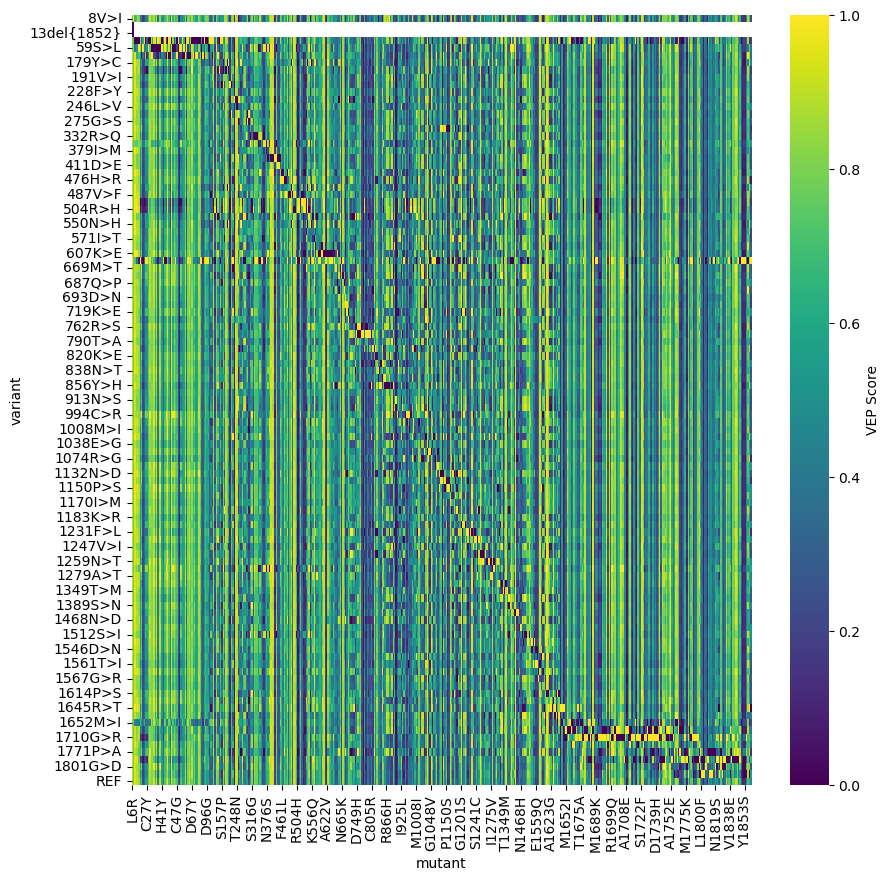

In [317]:
plt.figure(figsize=(10,10))
sns.heatmap(clinvar_vs_wt, cmap='viridis', cbar_kws={'label': 'VEP Score'})

In [268]:
outlier_df.loc[outlier_df["p_value"] < 0.05]["wt_variant"].nunique()

98

In [245]:
large_del_rows = clinvar_vs_wt.index[clinvar_vs_wt.index.str.contains('del{')]
large_del_rows

Index(['13del{1852}'], dtype='object', name='variant')

Text(0.5, 1.0, 'VEP Scores by Variant Group\np=2.21e-03, d=0.43')

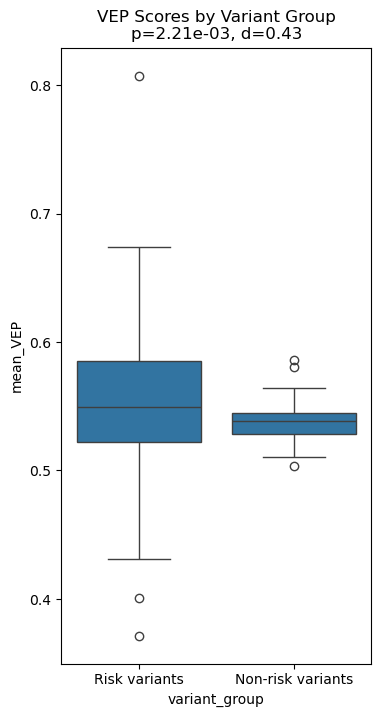

In [ ]:
dat = pd.concat([
    # Risk variants - exclude zeros and large deletions
    clinvar_vs_wt[~clinvar_vs_wt.index.isin(large_del_rows)][risk_variants].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Risk variants"),
    # Non-risk variants - exclude zeros and large deletions
    clinvar_vs_wt[~clinvar_vs_wt.index.isin(large_del_rows)][clinvar_vs_wt.columns.difference(risk_variants)].replace(0, np.nan).mean(axis=1, skipna=True).reset_index(name="mean_VEP").assign(variant_group="Non-risk variants")
], axis=0)
dat


# First ensure no duplicate labels in the data
dat = dat.reset_index(drop=True)

# Perform statistical test
from scipy import stats
# Handle NaN values by dropping them before statistical test
risk_data = dat[dat['variant_group'] == 'Risk variants']['mean_VEP'].dropna()
nonrisk_data = dat[dat['variant_group'] == 'Non-risk variants']['mean_VEP'].dropna()
stat, pval = stats.ttest_ind(risk_data, nonrisk_data)

# Calculate effect size (Cohen's d) manually since scipy.stats.cohens_d is not available
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)

effect_size = cohens_d(risk_data, nonrisk_data)

plt.figure(figsize=(4, 8))
sns.boxplot(data=dat, x="variant_group", y="mean_VEP")
plt.title(f'VEP Scores by Variant Group\np={pval:.2e}, d={effect_size:.2f}')

In [253]:
gwas_vep["is_risk_variant"] = gwas_vep["mutant"].isin(risk_variants)

In [257]:
gwas_vep["is_risk_variant"].value_counts() / gwas_vep.shape[0]









 

is_risk_variant
False    0.9375
True     0.0625
Name: count, dtype: float64

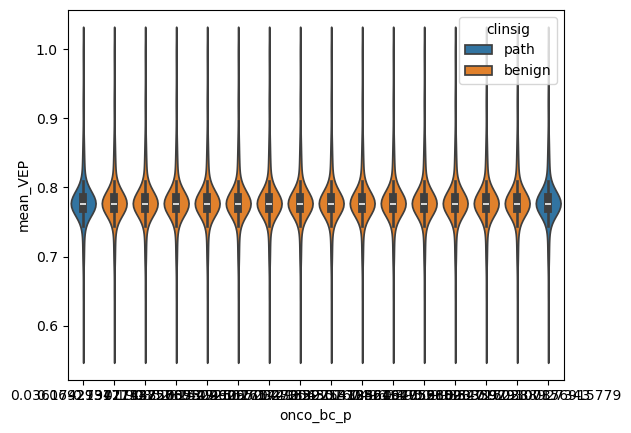

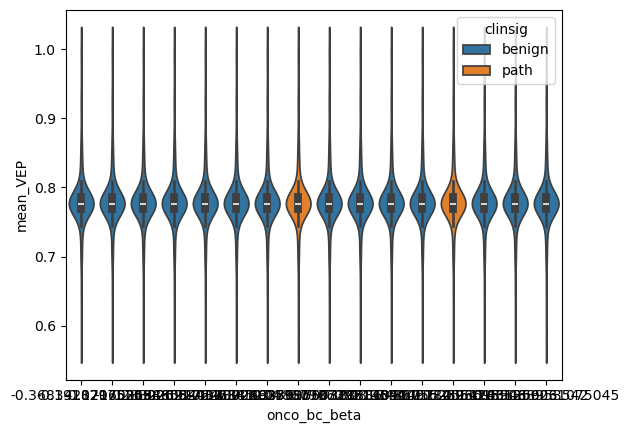

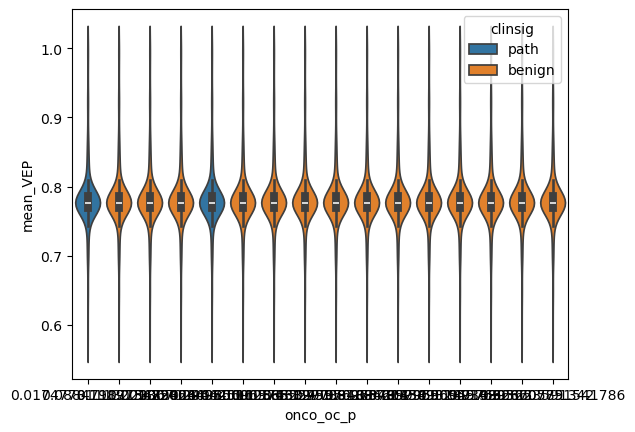

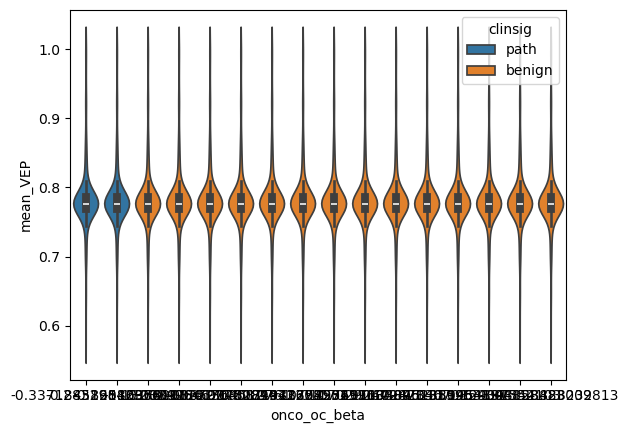

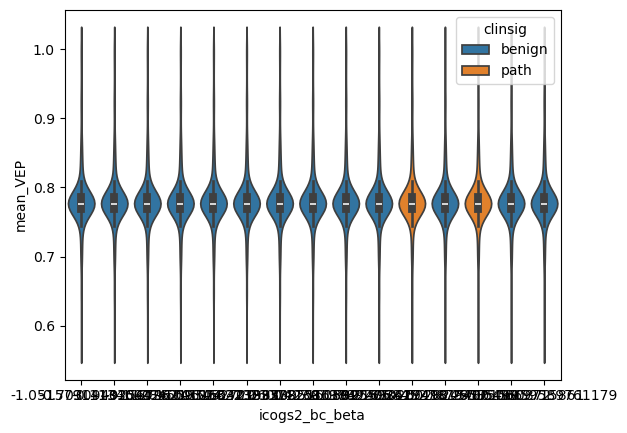

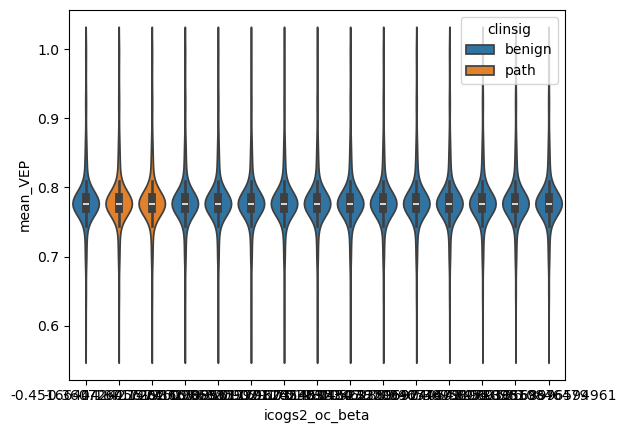

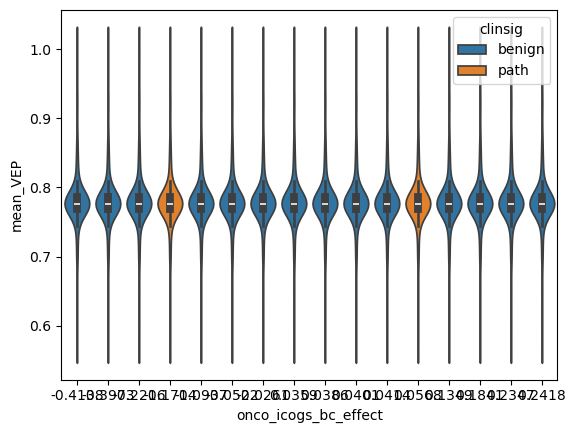

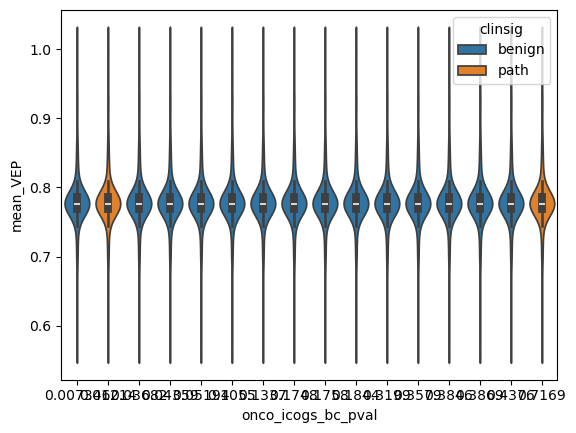

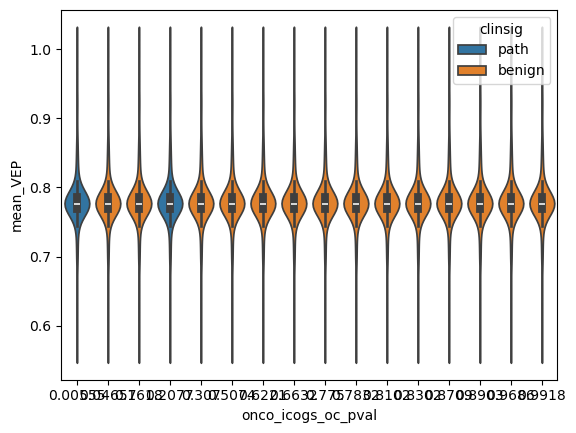

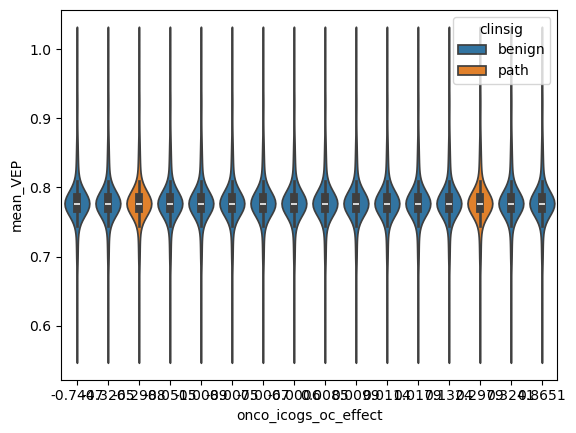

In [199]:
log_x = False
dat = gwas_vep.merge(clinvar_vs_wt[risk_variants].max(axis=1, skipna=True).reset_index(name="mean_VEP"))
for col in ["onco_bc_p", "onco_bc_beta", "onco_oc_p","onco_oc_beta", "icogs2_bc_beta","icogs2_oc_beta", "onco_icogs_bc_effect","onco_icogs_bc_pval","onco_icogs_oc_pval","onco_icogs_oc_effect"]:
    
    if log_x:
        x_data = np.log10(dat[col])
    else:
        x_data = dat[col]

    sns.violinplot(data=dat, x=x_data, y="mean_VEP", hue="clinsig")
    plt.show()


## UniProt Annotations

In [57]:
seqs = up.get_seqs("P38398")
seqs

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


[Seq('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQ...SHY')]

In [58]:
features_df = up.get_features("P38398")
features_df.head()

,id,type,start,end,description,evidence,original,variation,ref,length
0,PRO_0000055830,chain,0,1863,Breast cancer type 1 susceptibility protein,NaN,NaN,NaN,NaN,1863
1,<unknown id>,domain,1641,1736,BRCT 1,2,NaN,NaN,NaN,95
2,<unknown id>,domain,1755,1855,BRCT 2,2,NaN,NaN,NaN,100
3,<unknown id>,zinc finger region,23,65,RING-type,3,NaN,NaN,NaN,42
4,<unknown id>,region of interest,229,270,Disordered,4,NaN,NaN,NaN,41


In [27]:
# Transform VEP data from haplotype- to sample-level
vep_prot = vep_df[vep_df['protein'] == "NP_009225.1"].merge(haps_to_samples, on=["haplotype"], how="left")

rm_cols = ["sample","haplotype","is_ref","Super Population","Population","Gender","VEP"]
mutant_df = vep_prot.drop(columns=rm_cols).drop_duplicates()
# mutant_df = mutant_df.groupby([col for col in mutant_df.columns if col != 'VEP']).agg({"VEP":"mean"}).reset_index()
mutant_df["mutant_cluster"] = mutant_df["mutant"].map(variant_to_cluster)
# Count unique variants per cluster
cluster_variant_counts = mutant_df.groupby('mutant_cluster')['mutant'].nunique().reset_index()
cluster_variant_counts.columns = ['mutant_cluster', 'mutants_per_cluster']

# Merge with original dataframe
mutant_df = mutant_df.merge(cluster_variant_counts, on='mutant_cluster', how='left')

mutant_df


,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,scoring_strategy,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,ENST_haplosaurus,mutant_cluster,mutants_per_cluster
0,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,ENST00000357654,2,6
1,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,ENST00000357654,57,11
2,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045698,183951,T,G,.,PASS,183951,17:43045698,G,672,NM_007294.4,Transcript,missense_variant,5685,5572,1858,I/L,Atc/Ctc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_007294.4:c.5572A>C,NP_009225.1:p.Ile1858Leu,-,NaN,0.00006,184864,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_sp...,NC_000017.11:g.43045698T>G,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,765656957,NaN,BRCA1-HCI:BRCA1_00097|ClinGen:CA003726,NaN,NaN,NaN,NaN,NaN,0.791910,NaN,5,benign,ENST00000357654,60,64
3,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1856S,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,masked-marginals,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045704,55632,G,A,.,PASS,55632,17:43045704,A,672,NM_007294.4,Transcript,missense_variant,5679,5566,1856,P/S,Ccc/Tcc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5566C>T,NP_009225.1:p.Pro1856Ser,-,NaN,0.00002,70299,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|Heredi...,NC_000017.11:g.43045704G>A,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357274,NaN,ClinGen:CA003722,NaN,N

In [ ]:
records = up.import_uniprot("P38398")
seqs = up.get_seqs(records)
seqs

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/SeqIO/UniprotIO.py:65: BiopythonDeprecationWarning: Opening a UniProt XML file in text mode is deprecated, as it may lead to garbled characters. We recommend opening the file in binary mode; parsing UniProt XML files opened in text mode will no longer be supported in a future release of Biopython.
  warnings.warn(


[Seq('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQ...SHY')]

In [ ]:
/api/v1/uniprot/summary/{uniprot_acc}

Cluster 68 has 11 unique variants


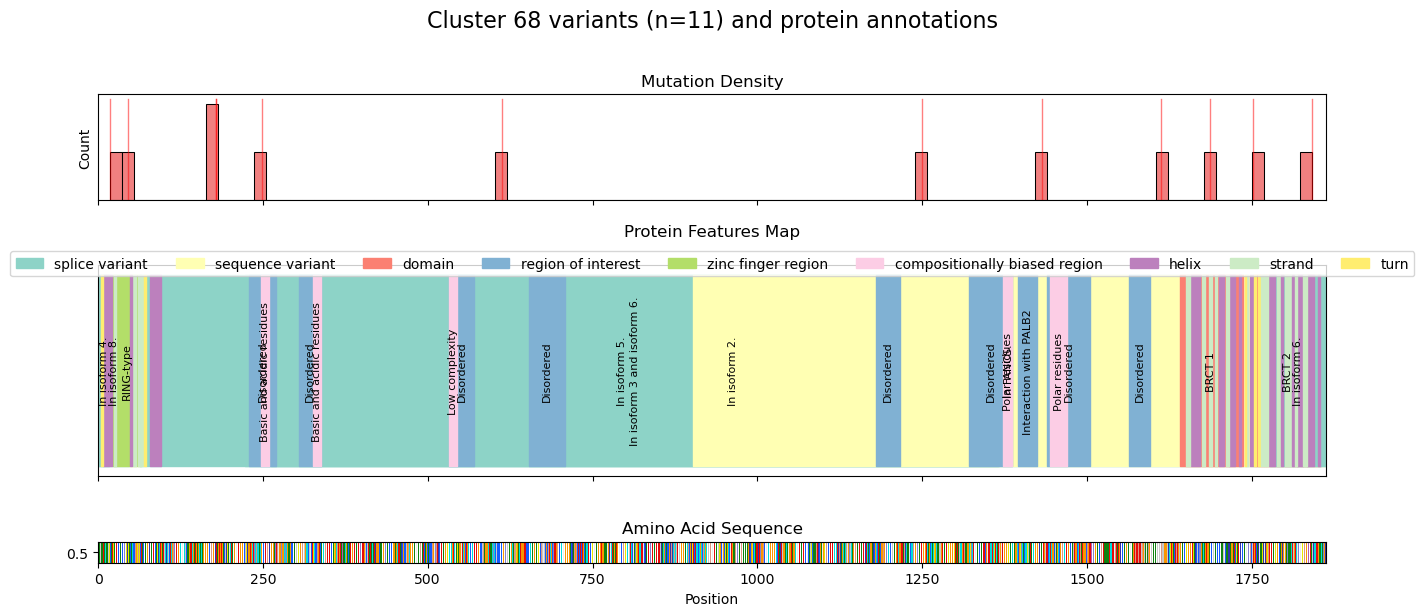

In [59]:

include_types = None
min_length = 2
exclude_types = ["chain",]
max_len = features_df.loc[features_df["type"] == "chain", "end"][0]


mutant_df = mutant_df.sort_values('mutants_per_cluster', ascending=False)
cluster_id = mutant_df["mutant_cluster"].unique()[9]
muts = mutant_df.loc[mutant_df["mutant_cluster"] == cluster_id]
# Merge annotation data from EnsemblVEP
# muts = muts.merge(cv_annot, on="mutant", how="left")



print(f"Cluster {cluster_id} has {muts['mutants_per_cluster'].iloc[0]} unique variants")

seq = str(seqs[0])

plot_df = features_df.copy()
plot_df.sort_values("length",ascending=False, inplace=True)

if include_types is not None:
    plot_df = plot_df[plot_df["type"].str.contains("|".join(include_types))]

if min_length is not None:
    plot_df = plot_df[plot_df["length"] >= min_length]

if exclude_types is not None:
    plot_df = plot_df[~plot_df["type"].str.contains("|".join(exclude_types))]

# Create figure with three subplots
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(15, 6), height_ratios=[0.5, 1, 0.1], sharex=True)

# Add overall title
fig.suptitle(f'Cluster {cluster_id} variants (n={muts["mutants_per_cluster"].iloc[0]}) and protein annotations', fontsize=16, y=1.02)

# Plot mutations and KDE on top subplot
sns.histplot(data=muts, 
             x='Protein_position', ax=ax0, fill=True, alpha=0.3, bins=100, fc='lightcoral')
y_max = ax0.get_ylim()[1]  # Get the maximum y value once
for pos in muts['Protein_position']:
    ax0.plot([pos, pos], [0, y_max], color='red', alpha=0.5, linewidth=1)
ax0.set_yticks([])
ax0.set_title('Mutation Density')

# Plot features on middle subplot
colors = plt.cm.Set3(np.linspace(0, 1, len(plot_df['type'].unique())))
type_to_color = dict(zip(plot_df['type'].unique(), colors))
for _, feat in plot_df.iterrows():
    if pd.notna(feat['start']) and pd.notna(feat['end']):
        ax1.fill_between([feat['start'], feat['end']], 
                        [-0.1, -0.1], [0.1, 0.1],
                        color=type_to_color[feat['type']],
                        alpha=1,
                        label=feat['type'] if feat['type'] not in ax1.get_legend_handles_labels()[1] else "")
        
        # Add description label if it exists
        if 'description' in feat and pd.notna(feat['description']):
            mid_point = (feat['start'] + feat['end']) / 2
            ax1.text(mid_point, 0, feat['description'],
                    rotation=90, ha='center', va='center',
                    fontsize=8)

# Define amino acid colors based on properties
aa_colors = {
    'A': '#C8C8C8',  # Alanine - Gray
    'C': '#E6E600',  # Cysteine - Yellow
    'D': '#E60A0A',  # Aspartic acid - Red
    'E': '#E60A0A',  # Glutamic acid - Red
    'F': '#3232AA',  # Phenylalanine - Blue
    'G': '#EBEBEB',  # Glycine - Light gray
    'H': '#8282D2',  # Histidine - Light blue
    'I': '#0F820F',  # Isoleucine - Green
    'K': '#145AFF',  # Lysine - Blue
    'L': '#0F820F',  # Leucine - Green
    'M': '#E6E600',  # Methionine - Yellow
    'N': '#00DCDC',  # Asparagine - Cyan
    'P': '#DC9682',  # Proline - Pink
    'Q': '#00DCDC',  # Glutamine - Cyan
    'R': '#145AFF',  # Arginine - Blue
    'S': '#FA9600',  # Serine - Orange
    'T': '#FA9600',  # Threonine - Orange
    'V': '#0F820F',  # Valine - Green
    'W': '#B45AB4',  # Tryptophan - Purple
    'Y': '#3232AA'   # Tyrosine - Blue
}

# Plot amino acids on bottom subplot
if seq:
    for i, aa in enumerate(seq):
        ax2.add_patch(plt.Rectangle((i-0.4, 0), 0.8, 1, 
                                  facecolor=aa_colors.get(aa, '#FFFFFF'),
                                  linewidth=0.1))
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.5])
    ax2.set_title('Amino Acid Sequence', y=1)
else:
    print("No sequence found")
    ax2.plot([0, max_len], [0.5, 0.5], 'k-', alpha=0.5, linewidth=5, label='Sequence')

# Configure plot appearance
ax1.set_title('Protein Features Map', y=1.1)
ax1.set_yticks([])
ax1.legend(bbox_to_anchor=(0.5, 1.1), loc='upper center', ncol=10)
ax1.set_xlim(0, max_len)

ax2.set_xlabel('Position')
ax2.set_xlim(0, max_len)

plt.tight_layout()

In [44]:
import pyranges as pr

# Convert mutations to pyranges format
mut_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(muts),
    starts=muts["Protein_position"] - 1,  # Convert to 0-based
    ends=muts["Protein_position"],
    strands=muts["STRAND"],
)
mut_ranges.mutant = muts["mutant"]  # Use mutant instead of Name

# Convert features to pyranges format
feature_ranges = pr.PyRanges(
    chromosomes=["chr1"] * len(features_df),
    starts=features_df["start"],
    ends=features_df["end"],
    strands=["+"] * len(features_df)
)
feature_ranges.feature_type = features_df["type"]  # Changed Name to feature_type

# Find overlaps between mutations and features
overlaps = mut_ranges.join(feature_ranges, suffix="_feature")

# Convert back to pandas DataFrame
overlap_df = overlaps.df
overlap_df

# Count overlaps per feature type
# feature_counts = overlap_df.groupby("feature_type")["feature_type"].count().reset_index()
# feature_counts.columns = ["feature_type", "overlap_count"]

# print("\nOverlap counts by feature type:")
# print(feature_counts.sort_values("overlap_count", ascending=False))

# # Add overlap information to muts DataFrame
# muts["overlapping_features"] = muts["mutant"].map(
#     overlap_df.groupby("mutant")["feature_type"].agg(list).to_dict()
# )


join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


,Chromosome,Start,End,Strand,mutant,Start_feature,End_feature,Strand_feature,feature_type
0,chr1,44,45,NaN,K45Q,0,1863,+,chain
1,chr1,44,45,NaN,K45Q,0,47,+,splice variant
2,chr1,44,45,NaN,K45Q,23,65,+,zinc finger region
3,chr1,44,45,NaN,K45Q,44,45,+,sequence variant
4,chr1,17,18,NaN,M18T,0,1863,+,chain
5,chr1,17,18,NaN,M18T,0,47,+,splice variant
6,chr1,17,18,NaN,M18T,7,21,+,helix
7,chr1,17,18,NaN,M18T,17,18,+,sequence variant
8,chr1,178,179,NaN,Y179C,0,1863,+,chain
9,chr1,178,179,NaN,Y179C,63,1863,+,splice variant


In [ ]:
features_df["type"].value_counts()

type
sequence variant                 170
modified residue                  30
mutagenesis site                  27
strand                            19
helix                             15
cross-link                        13
region of interest                 9
splice variant                     8
sequence conflict                  8
compositionally biased region      5
turn                               5
domain                             2
zinc finger region                 1
chain                              1
Name: count, dtype: int64

In [ ]:
# spliceai_cols = [x for x in muts.columns if x.startswith("SpliceAI_pred_D")]

# annot_cols  = [
#     #### CADD ####
#     "CADD_PHRED","CADD_RAW",

#     #### REVEL ####
#     "REVEL",

#     #### MaveDB ####
#    "MaveDB_score_mean", 
#    "MaveDB_score_abs_mean",
# #    "MaveDB_score_min",
# #    "MaveDB_score_max",


#     #### EVE ####
#     "EVE_SCORE",
    
#     #### ClinPred ####
#     "ClinPred",

#     #### RF ####
#     "rf_score",

#     #### AdaScore ####
#     "ada_score",

#     #### MaxEntScan ####
#     'MaxEntScan_diff',
    
#     #### LOEUF ####
#     "LOEUF",
    
#     #### AlphaMissense ####
#     "am_pathogenicity",

#     ### SpliceAI ####
#     *spliceai_cols,
#     #### OpenTargets ####
# #    "OpenTargets_l2g",


#     #### Allele Frequences ####
#     "gnomADe_AF","gnomADg_AF","AF_TGP",
#     "AllOfUs_gvs_all_af", "AllOfUs_gvs_max_af",

#     # "MOTIF_SCORE_CHANGE",

#     #### pHaplo ####
#     # "pHaplo" => "Probability of haploinsufficiency (deletion intolerance) of the affected gene",
#     # "pTriplo" => "Probability of triplosensitivity (duplication intolerance) of the affected gene"
#     "pHaplo",
#     "pTriplo",


#     ### Conservation ####
#     "SIFT_score",
#     "PolyPhen_score",
#     ]


#  # Create heatmap with protein position on x-axis and other features on y-axis
#  plt.figure(figsize=(15, 8))
#  sns.heatmap(cv_annot.loc[cv_annot["SYMBOL"] == "BRCA1" ,["Protein_position"]+[x for x in annot_cols if x in cv_annot.columns]].set_index("Protein_position").T
#             cmap='RdBu_r',
#             center=0,
#             annot=True,
#             fmt='.2f',
#             square=True)
#  plt.title('Feature Values by Protein Position')
#  plt.xlabel('Protein Position')
#  plt.ylabel('Features')
#  plt.tight_layout()